In [ ]:
#Connect with colab

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# The RAVDESS Database

In [ ]:
!unzip '/content/drive/MyDrive/speech-emotion-recognition-ravdess-data.zip' -d '/content/RAVDESS_ORG'

Archive:  /content/drive/MyDrive/speech-emotion-recognition-ravdess-data.zip
   creating: /content/RAVDESS_ORG/Actor_01/
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: /content/RAVDESS_ORG/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: /content/RAVDESS_ORG/Actor

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
# Buscamos generar un vector con el nombre del archivo, la emocion asociada y la ruta para llegar a el.
# Seria mas boby hacer una matriz con todas las bases de datos,..., pero creo que asi resulta pedagogico verlo 1 a 1.
Xr = []
yr = []
zr = []

for file in glob.glob("/content/RAVDESS_ORG/Actor_*/*.wav"):
    # Obtener nombre y Ubicacion de los archivos de audio
    rootname = os.path.dirname(file)
    basename = os.path.basename(file)
    # La emocion esta contenida en el nombre del archivo
    emotion = basename.split("-")[2]
    Xr.append(basename)
    yr.append(emotion)
    zr.append(rootname)
# creamos una matriz con los dos vectores
a = np.array(Xr)
b = np.array(yr)
c = np.array(zr)
docr = np.column_stack((a, b, c))
# Pasamos a Dataframe Panda
df_docr = pd.DataFrame(docr, columns = ['File','Emotion','Root'])
print(df_docr)

                          File Emotion                           Root
0     03-01-05-02-02-01-10.wav      05  /content/RAVDESS_ORG/Actor_10
1     03-01-03-01-01-02-10.wav      03  /content/RAVDESS_ORG/Actor_10
2     03-01-05-01-02-01-10.wav      05  /content/RAVDESS_ORG/Actor_10
3     03-01-05-02-02-02-10.wav      05  /content/RAVDESS_ORG/Actor_10
4     03-01-05-01-02-02-10.wav      05  /content/RAVDESS_ORG/Actor_10
...                        ...     ...                            ...
1435  03-01-07-02-02-01-03.wav      07  /content/RAVDESS_ORG/Actor_03
1436  03-01-03-02-01-02-03.wav      03  /content/RAVDESS_ORG/Actor_03
1437  03-01-06-01-01-01-03.wav      06  /content/RAVDESS_ORG/Actor_03
1438  03-01-08-01-01-01-03.wav      08  /content/RAVDESS_ORG/Actor_03
1439  03-01-08-02-01-02-03.wav      08  /content/RAVDESS_ORG/Actor_03

[1440 rows x 3 columns]


<Axes: xlabel='Emotion'>

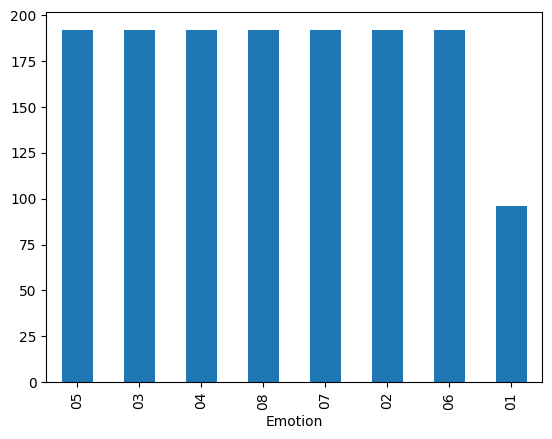

In [ ]:
#Haremos un histograma con el munero de archivos por categoria emocional
df_docr['Emotion'].value_counts().plot.bar()

In [ ]:
unique, counts = np.unique(b, return_counts=True)
print (np.asarray((unique, counts)).T)

[['01' '96']
 ['02' '192']
 ['03' '192']
 ['04' '192']
 ['05' '192']
 ['06' '192']
 ['07' '192']
 ['08' '192']]


In [ ]:
# Tenemos que poder standarizar las bases de datos.
#En este caso reduciomos las emociones a dos categorias (-1,1).
#replace_values = {'01' : 0, '02' : 1, '03' : 1, '04' : -1, '05' : -1, '06' : -1, '07' : -1, '08' : 1}
replace_values = {'01' : 'Neutral', '02' : 'Calm', '03' : 'Happy', '04' : 'Sad', '05' : 'Angry', '06' : 'Fearful', '07' : 'Disgust', '08' : 'Surprised'}
df_docr = df_docr.replace({'Emotion': replace_values})
df_docr


,File,Emotion,Root
0,03-01-05-02-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10
1,03-01-03-01-01-02-10.wav,Happy,/content/RAVDESS_ORG/Actor_10
2,03-01-05-01-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10
3,03-01-05-02-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10
4,03-01-05-01-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10
...,...,...,...
1435,03-01-07-02-02-01-03.wav,Disgust,/content/RAVDESS_ORG/Actor_03
1436,03-01-03-02-01-02-03.wav,Happy,/content/RAVDESS_ORG/Actor_03
1437,03-01-06-01-01-01-03.wav,Fearful,/content/RAVDESS_ORG/Actor_03
1438,03-01-08-01-01-01-03.wav,Surprised,/content/RAVDESS_ORG/Actor_03


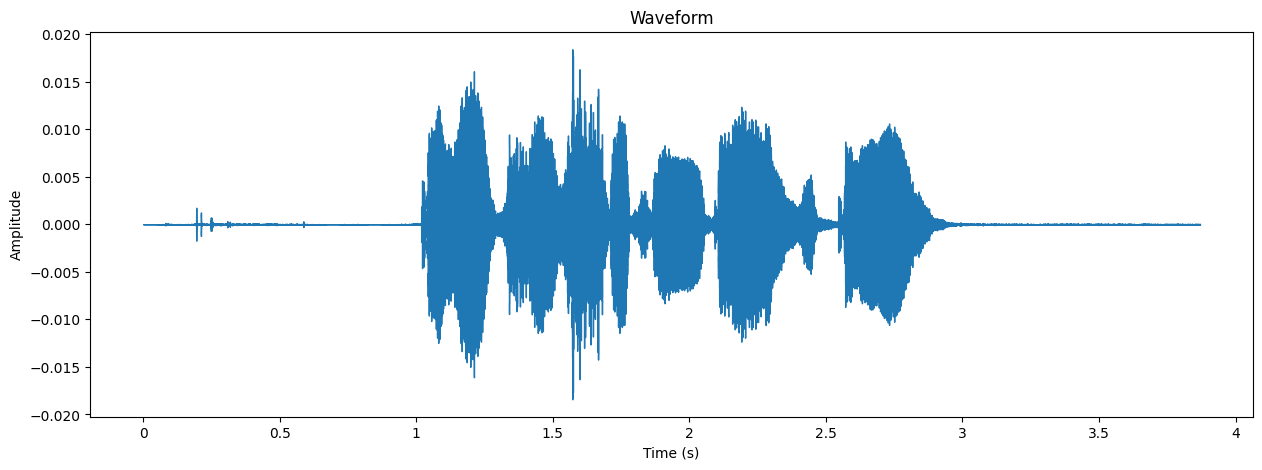

In [ ]:

import librosa
import librosa.display
from IPython.display import Audio
import matplotlib.pyplot as plt



fname = '/content/RAVDESS_ORG/Actor_24/03-01-02-01-02-01-24.wav'
# Load audio
data, sampling_rate = librosa.load(fname)

# Plot waveform
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


🎧 Playing Emotion Angry: /content/RAVDESS_ORG/Actor_18/03-01-05-02-02-01-18.wav


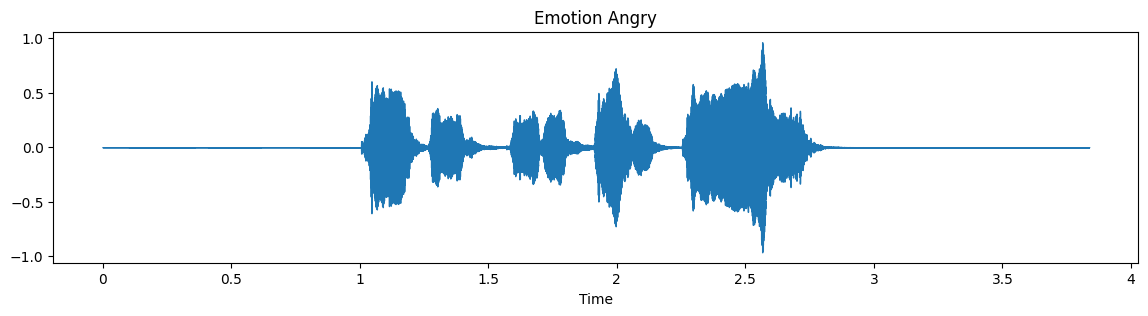


🎧 Playing Emotion Calm: /content/RAVDESS_ORG/Actor_12/03-01-02-02-01-02-12.wav


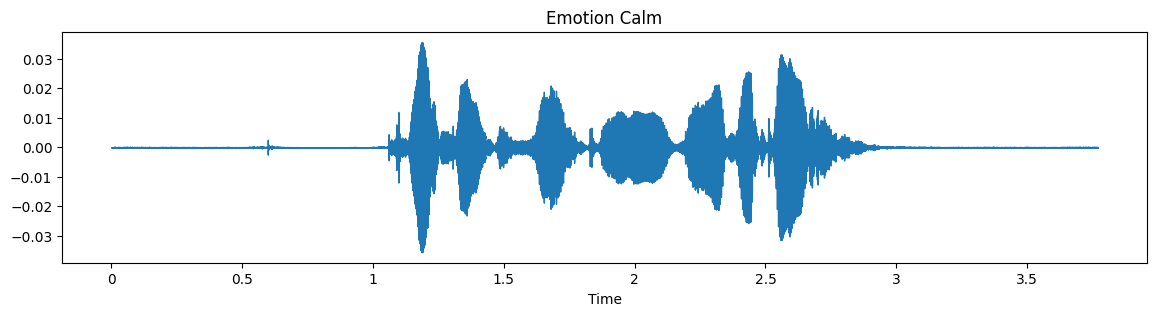


🎧 Playing Emotion Disgust: /content/RAVDESS_ORG/Actor_08/03-01-07-02-01-02-08.wav


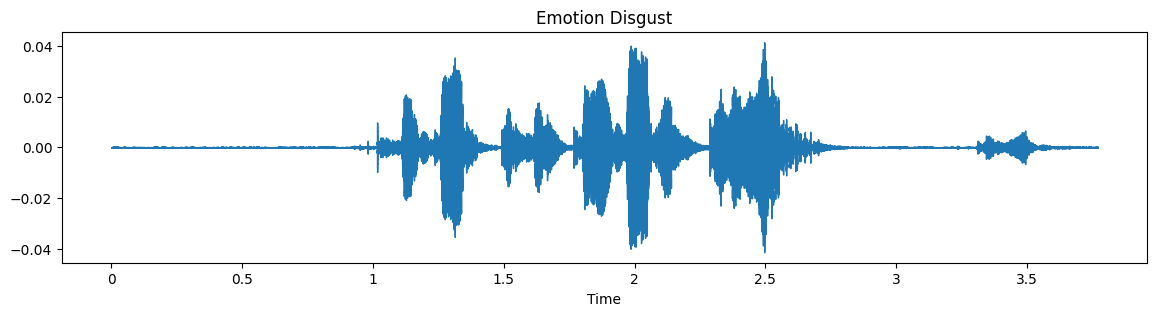


🎧 Playing Emotion Fearful: /content/RAVDESS_ORG/Actor_01/03-01-06-01-01-01-01.wav


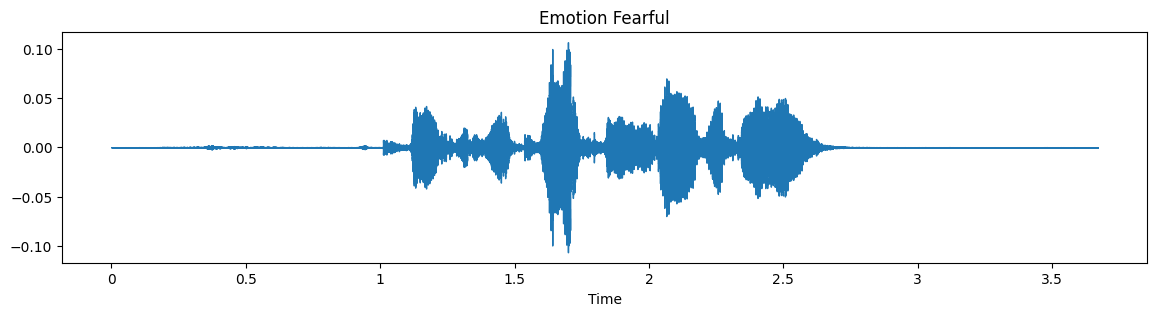


🎧 Playing Emotion Happy: /content/RAVDESS_ORG/Actor_07/03-01-03-02-01-02-07.wav


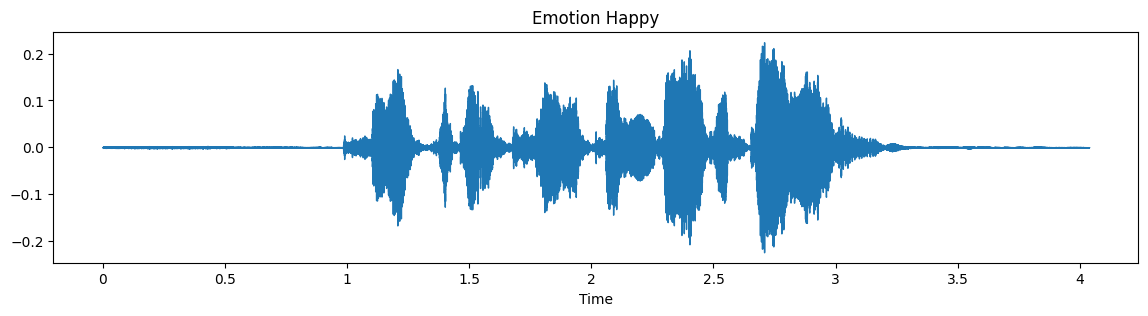


🎧 Playing Emotion Neutral: /content/RAVDESS_ORG/Actor_08/03-01-01-01-01-02-08.wav


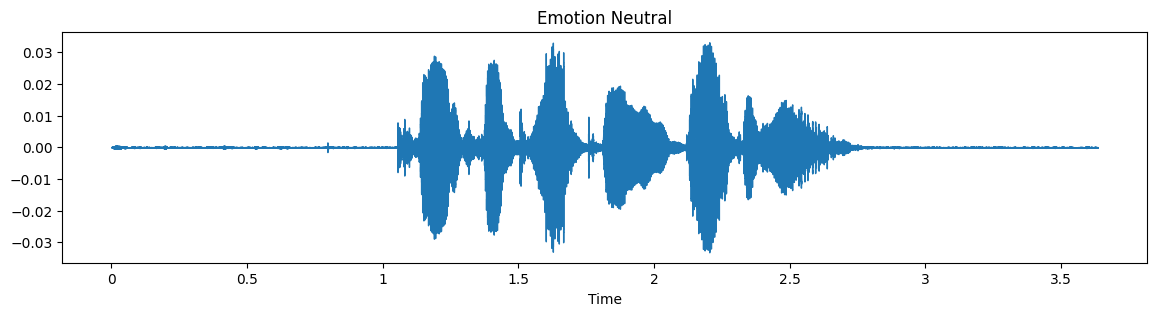


🎧 Playing Emotion Sad: /content/RAVDESS_ORG/Actor_16/03-01-04-01-01-01-16.wav


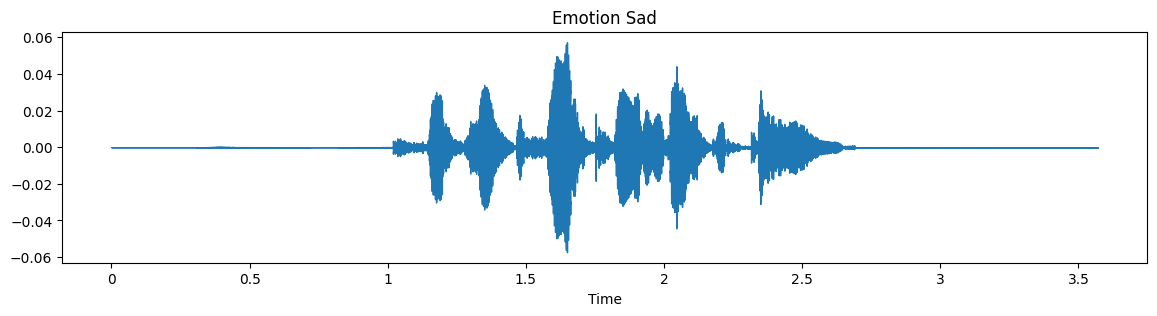


🎧 Playing Emotion Surprised: /content/RAVDESS_ORG/Actor_06/03-01-08-01-01-01-06.wav


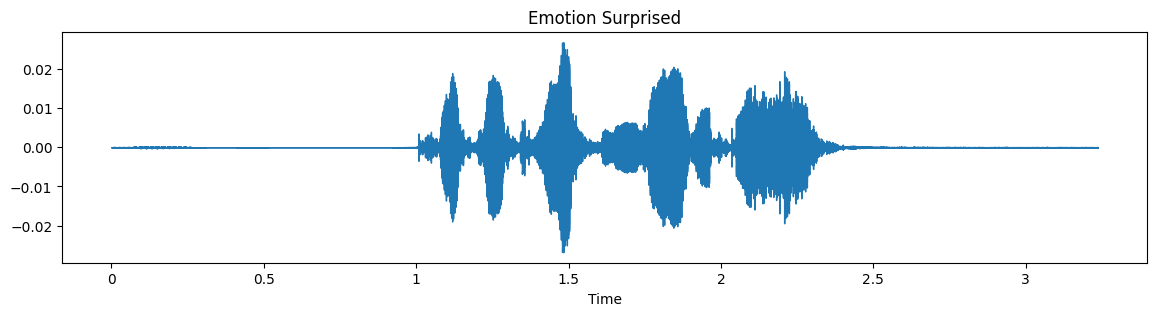

In [ ]:
import pandas as pd
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display



# Sample one file per emotion
replace_values = {'01' : 'Neutral', '02' : 'Calm', '03' : 'Happy', '04' : 'Sad', '05' : 'Angry', '06' : 'Fearful', '07' : 'Disgust', '08' : 'Surprised'}
df_docr = df_docr.replace({'Emotion': replace_values})

sampled = df_docr.groupby('Emotion').sample(n=1, random_state=42)

for idx, row in sampled.iterrows():
    file_path = f"{row['Root']}/{row['File'].strip()}"
    print(f"\n🎧 Playing Emotion {row['Emotion']}: {file_path}")

    # Load and plot
    data, sr = librosa.load(file_path)

    plt.figure(figsize=(14, 3))
    librosa.display.waveshow(data, sr=sr)
    plt.title(f"Emotion {row['Emotion']}")
    plt.show()

    # Play audio
    display(Audio(data=data, rate=sr))


# Features selection

In [ ]:
!pip install opensmile


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.0/996.0 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 22.0 MB/s eta 0:00:00


In [ ]:
import opensmile
import pandas as pd

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

features = smile.process_file(filename)

# Print all feature names (columns)
print("Feature names:\n")
for i, col in enumerate(features.columns):
    print(f"{i+1:2d}. {col}")

# Print the corresponding values (since it's a 1-row DataFrame)
print("\nFeature values:\n")
print(features.iloc[0].to_string())

Feature names:

 1. F0semitoneFrom27.5Hz_sma3nz_amean
 2. F0semitoneFrom27.5Hz_sma3nz_stddevNorm
 3. F0semitoneFrom27.5Hz_sma3nz_percentile20.0
 4. F0semitoneFrom27.5Hz_sma3nz_percentile50.0
 5. F0semitoneFrom27.5Hz_sma3nz_percentile80.0
 6. F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2
 7. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope
 8. F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope
 9. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope
10. F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope
11. loudness_sma3_amean
12. loudness_sma3_stddevNorm
13. loudness_sma3_percentile20.0
14. loudness_sma3_percentile50.0
15. loudness_sma3_percentile80.0
16. loudness_sma3_pctlrange0-2
17. loudness_sma3_meanRisingSlope
18. loudness_sma3_stddevRisingSlope
19. loudness_sma3_meanFallingSlope
20. loudness_sma3_stddevFallingSlope
21. spectralFlux_sma3_amean
22. spectralFlux_sma3_stddevNorm
23. mfcc1_sma3_amean
24. mfcc1_sma3_stddevNorm
25. mfcc2_sma3_amean
26. mfcc2_sma3_stddevNorm
27. mfcc3_sma3_amean
28. mfcc3_sma3_std

In [ ]:
import opensmile
import pandas as pd
import os
from tqdm import tqdm  # progress bar

# Initialize OpenSMILE extractor
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

# Assuming your dataframe looks like this:
# df_docr has columns: "File", "Emotion", "Root"
# We'll compute full path to the file
df_docr["Path"] = df_docr.apply(lambda row: os.path.join(row["Root"], row["File"]), axis=1)

# Create a list to store all features
all_features = []

# Iterate through each audio file path and extract features
for path in tqdm(df_docr["Path"], desc="Extracting features"):
    try:
        feats = smile.process_file(path)
        # feats is a DataFrame with 1 row (index = path), we reset index to clean it
        feats.reset_index(drop=True, inplace=True)
        all_features.append(feats.iloc[0])
    except Exception as e:
        print(f"Error processing {path}: {e}")
        all_features.append(pd.Series([None]*88, index=smile.feature_names))  # fill with NaN

# Convert all features into a DataFrame
df_features = pd.DataFrame(all_features)






Extracting features: 100%|██████████| 1440/1440 [03:47<00:00,  6.34it/s]


In [ ]:
df_features

,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,42.944069,0.107373,37.567955,43.100674,47.403534,9.835579,367.558319,522.012024,47.623638,22.555136,...,0.051557,0.021143,0.069896,2.072539,1.574803,0.205000,0.137447,0.406667,0.437328,-20.424952
0,40.652424,0.064248,38.464455,41.441025,42.604507,4.140053,89.872498,127.177780,53.571644,35.183468,...,0.031080,0.024892,0.026161,2.312139,1.173021,0.297500,0.193827,0.426000,0.451291,-30.586109
0,34.737854,0.060301,33.147251,34.287140,36.573315,3.426064,75.348778,59.062286,17.708847,16.894632,...,0.030052,0.025025,0.017507,2.933985,1.237624,0.306000,0.168950,0.400000,0.430194,-33.042236
0,40.242641,0.100236,37.839901,40.133690,44.284771,6.444870,177.944931,212.104584,29.378778,18.575603,...,0.038861,0.023983,0.025719,2.427185,0.982801,0.445000,0.196787,0.547500,0.458714,-20.703802
0,34.970997,0.050141,33.830238,34.376793,36.545563,2.715324,30.358408,11.036998,17.604639,19.088400,...,0.037800,0.023268,0.021745,2.669903,1.481482,0.263333,0.285871,0.334286,0.422505,-32.660904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,28.487143,0.103432,24.934540,29.178436,30.761175,5.826635,146.155960,44.435535,18.084333,4.774724,...,0.049886,0.010685,0.022899,3.141361,2.122016,0.112500,0.087142,0.267000,0.252945,-36.981171
0,37.864285,0.102870,36.379803,38.597137,40.198093,3.818291,77.541412,58.140713,29.627527,22.092630,...,0.040303,0.027253,0.014143,1.594533,1.152074,0.424000,0.207711,0.351667,0.432412,-24.918018
0,28.953190,0.094515,26.459208,29.784376,31.390781,4.931574,53.524578,39.889191,86.659897,67.990471,...,0.052018,0.024537,0.015083,2.688172,2.452316,0.088889,0.045325,0.268000,0.365508,-43.789917
0,36.582073,0.095529,35.000317,36.121796,39.664997,4.664680,73.408897,20.938553,36.912861,47.749367,...,0.077950,0.037106,0.029000,2.484472,1.261830,0.217500,0.192792,0.550000,0.480260,-39.159958


In [ ]:
df_combined = pd.concat([df_docr.reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)


In [ ]:
df_combined

,File,Emotion,Root,Path,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,03-01-05-02-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-02-02-0...,42.944069,0.107373,37.567955,43.100674,47.403534,9.835579,...,0.051557,0.021143,0.069896,2.072539,1.574803,0.205000,0.137447,0.406667,0.437328,-20.424952
1,03-01-03-01-01-02-10.wav,Happy,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-03-01-01-0...,40.652424,0.064248,38.464455,41.441025,42.604507,4.140053,...,0.031080,0.024892,0.026161,2.312139,1.173021,0.297500,0.193827,0.426000,0.451291,-30.586109
2,03-01-05-01-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-01-02-0...,34.737854,0.060301,33.147251,34.287140,36.573315,3.426064,...,0.030052,0.025025,0.017507,2.933985,1.237624,0.306000,0.168950,0.400000,0.430194,-33.042236
3,03-01-05-02-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-02-02-0...,40.242641,0.100236,37.839901,40.133690,44.284771,6.444870,...,0.038861,0.023983,0.025719,2.427185,0.982801,0.445000,0.196787,0.547500,0.458714,-20.703802
4,03-01-05-01-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-01-02-0...,34.970997,0.050141,33.830238,34.376793,36.545563,2.715324,...,0.037800,0.023268,0.021745,2.669903,1.481482,0.263333,0.285871,0.334286,0.422505,-32.660904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,03-01-07-02-02-01-03.wav,Disgust,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-07-02-02-0...,28.487143,0.103432,24.934540,29.178436,30.761175,5.826635,...,0.049886,0.010685,0.022899,3.141361,2.122016,0.112500,0.087142,0.267000,0.252945,-36.981171
1436,03-01-03-02-01-02-03.wav,Happy,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-03-02-01-0...,37.864285,0.102870,36.379803,38.597137,40.198093,3.818291,...,0.040303,0.027253,0.014143,1.594533,1.152074,0.424000,0.207711,0.351667,0.432412,-24.918018
1437,03-01-06-01-01-01-03.wav,Fearful,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-06-01-01-0...,28.953190,0.094515,26.459208,29.784376,31.390781,4.931574,...,0.052018,0.024537,0.015083,2.688172,2.452316,0.088889,0.045325,0.268000,0.365508,-43.789917
1438,03-01-08-01-01-01-03.wav,Surprised,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-08-01-01-0...,36.582073,0.095529,35.000317,36.121796,39.664997,4.664680,...,0.077950,0.037106,0.029000,2.484472,1.261830,0.217500,0.192792,0.550000,0.480260,-39.159958


In [ ]:
# Check how many NaNs exist in each column
nan_counts = df_features.isna().sum()

# Show only columns with NaNs
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [ ]:

# Save to CSV
df_combined.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/RAVDESS_eGeMAPS._features.csv", index=False)

In [ ]:
import pandas as pd
# --- 1. Load CSV file ---
file_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/RAVDESS_eGeMAPS._features.csv"
df_combined = pd.read_csv(file_path)

In [ ]:
df_combined

,File,Emotion,Root,Path,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,03-01-05-02-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-02-02-0...,42.944070,0.107373,37.567955,43.100674,47.403534,9.835579,...,0.051557,0.021143,0.069896,2.072539,1.574803,0.205000,0.137447,0.406667,0.437328,-20.424952
1,03-01-03-01-01-02-10.wav,Happy,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-03-01-01-0...,40.652424,0.064248,38.464455,41.441025,42.604507,4.140053,...,0.031080,0.024892,0.026161,2.312139,1.173021,0.297500,0.193827,0.426000,0.451291,-30.586110
2,03-01-05-01-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-01-02-0...,34.737854,0.060301,33.147250,34.287140,36.573315,3.426064,...,0.030052,0.025025,0.017507,2.933985,1.237624,0.306000,0.168950,0.400000,0.430194,-33.042236
3,03-01-05-02-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-02-02-0...,40.242640,0.100236,37.839900,40.133690,44.284770,6.444870,...,0.038861,0.023983,0.025719,2.427185,0.982801,0.445000,0.196787,0.547500,0.458714,-20.703802
4,03-01-05-01-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-01-02-0...,34.970997,0.050141,33.830240,34.376793,36.545563,2.715324,...,0.037800,0.023268,0.021745,2.669903,1.481482,0.263333,0.285871,0.334286,0.422505,-32.660904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,03-01-07-02-02-01-03.wav,Disgust,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-07-02-02-0...,28.487143,0.103432,24.934540,29.178436,30.761175,5.826635,...,0.049886,0.010685,0.022899,3.141361,2.122016,0.112500,0.087142,0.267000,0.252945,-36.981170
1436,03-01-03-02-01-02-03.wav,Happy,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-03-02-01-0...,37.864285,0.102870,36.379803,38.597137,40.198093,3.818291,...,0.040303,0.027253,0.014143,1.594533,1.152074,0.424000,0.207711,0.351667,0.432412,-24.918018
1437,03-01-06-01-01-01-03.wav,Fearful,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-06-01-01-0...,28.953190,0.094515,26.459208,29.784376,31.390781,4.931574,...,0.052018,0.024537,0.015083,2.688172,2.452316,0.088889,0.045325,0.268000,0.365508,-43.789917
1438,03-01-08-01-01-01-03.wav,Surprised,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-08-01-01-0...,36.582073,0.095529,35.000317,36.121796,39.664997,4.664681,...,0.077950,0.037106,0.029000,2.484472,1.261830,0.217500,0.192792,0.550000,0.480260,-39.159958


In [ ]:
# List of columns to exclude
columns_to_exclude = ['File', 'Root', 'Path']

# Drop specified columns from the DataFrame
df_combined = df_combined.drop(columns=columns_to_exclude, errors='ignore')

# If index is present and needs to be dropped as well
if df_combined.index.name is not None:
    df_combined.reset_index(drop=True, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Encode 'Emotion' column to numerical values
le = LabelEncoder()
df_combined['Emotion'] = le.fit_transform(df_combined['Emotion'])

# Drop unwanted columns
columns_to_exclude = ['File', 'Root', 'Path']
df_features = df_combined.drop(columns=columns_to_exclude, errors='ignore')

# Reset index if needed
df_features.reset_index(drop=True, inplace=True)

# Separate features and target variable
X = df_features.drop(columns=['Emotion'])
y = df_features['Emotion']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)  # max_iter increased to avoid convergence issues
lr_model.fit(X_train, y_train)

# Get feature importance using SelectFromModel
sfm = SelectFromModel(lr_model, prefit=True)
selected_features = X.columns[sfm.get_support()]

# Display the selected features for each emotion
for emotion in df_combined['Emotion'].unique():
    emotion_label = le.inverse_transform([emotion])[0]
    print(f"\nMost important features for {emotion_label}:")
    print(selected_features.tolist())



Most important features for Angry:
['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc3_sma3_amean', 'mfcc4_sma3_amean', 'HNRdBACF_sma3nz_amean', 'logRelF0-H1-H2_sma3nz_amean', 'logRelF0-H1-H2_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean', 'F1amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_amean', 'alphaRatioV_sma3nz_amean', 'hammarbergIndexV_sma3nz_amean', 'slopeV500-1500_sma3nz_stddevNorm', 'mfcc1V_sma3nz_amean', 'mfcc2V_sma3nz_amean', 'mfcc3V_sma3nz_amean', 'mfcc4V_sma3nz_amean', 'alphaRatioUV_sma3nz_amean', 'hammarbergIndexUV_sma3nz_amean', 'equ

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


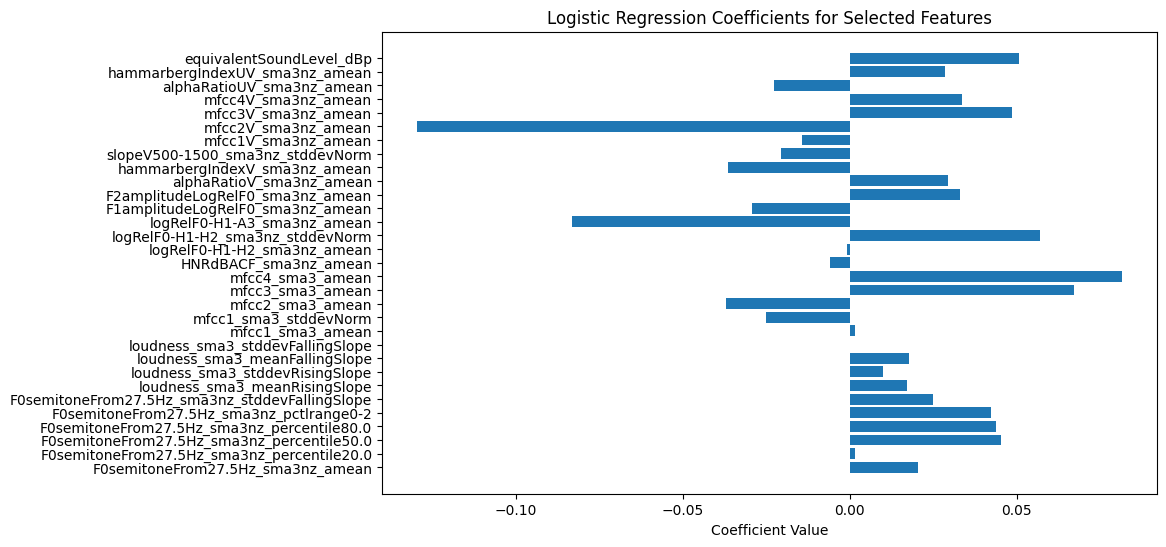

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance using SelectFromModel
sfm = SelectFromModel(lr_model, prefit=True)
selected_features = X.columns[sfm.get_support()]


# Plot the importance of selected features
plt.figure(figsize=(10, 6))
plt.barh(selected_features, lr_model.coef_[4][sfm.get_support()])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients for Selected Features')
plt.show()

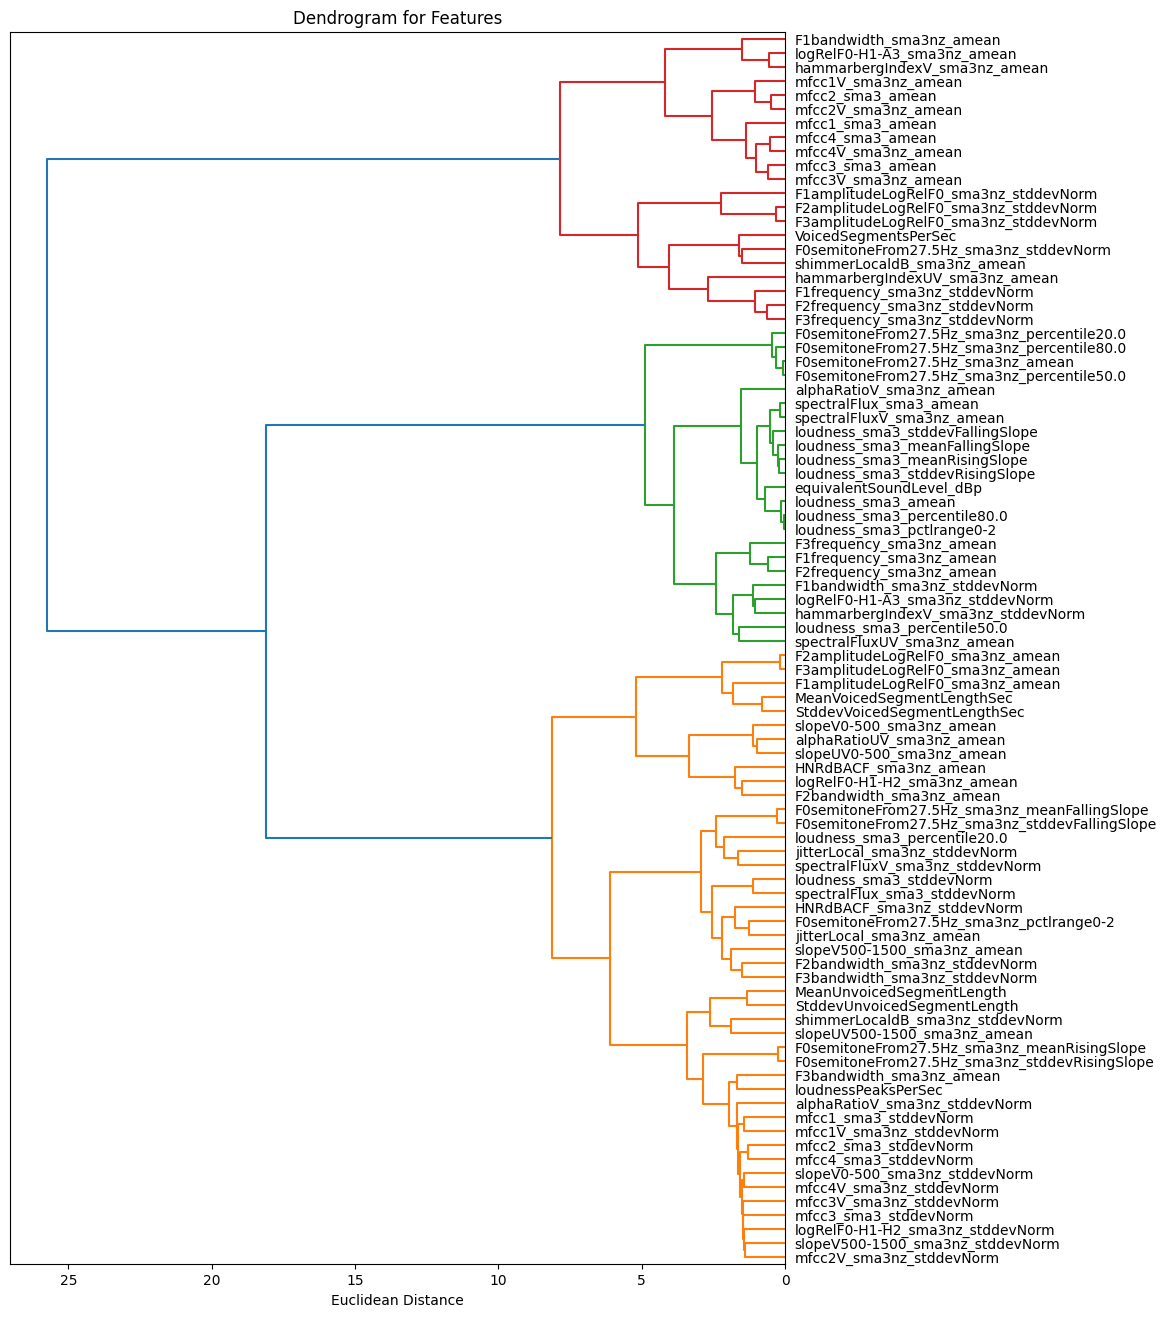

In [ ]:
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
import seaborn as sns

# Perform hierarchical clustering
corr = X.corr()
linkage_matrix = hierarchy.ward(corr)

# Plot the dendrogram
plt.figure(figsize=(10, 16))
dendrogram = hierarchy.dendrogram(linkage_matrix, labels=X.columns, orientation='left', distance_sort='descending', leaf_font_size=10)
plt.title('Dendrogram for Features')
plt.xlabel('Euclidean Distance')
plt.show()

# MLP

## MLP eGeMap

Epoch 1/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2139 - loss: 2.2124 - val_accuracy: 0.4062 - val_loss: 1.6658
Epoch 2/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3554 - loss: 1.7090 - val_accuracy: 0.5000 - val_loss: 1.4703
Epoch 3/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3980 - loss: 1.5346 - val_accuracy: 0.5278 - val_loss: 1.3452
Epoch 4/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4776 - loss: 1.4048 - val_accuracy: 0.5764 - val_loss: 1.2595
Epoch 5/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4760 - loss: 1.4143 - val_accuracy: 0.6181 - val_loss: 1.1838
Epoch 6/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5288 - loss: 1.2764 - val_accuracy: 0.6146 - val_loss: 1.1187
Epoch 7/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5527 - loss: 1.1886 - val_accuracy: 0.6389 - val_loss: 1.0757
Epoch 8/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5968 - loss: 1.1416 - val_

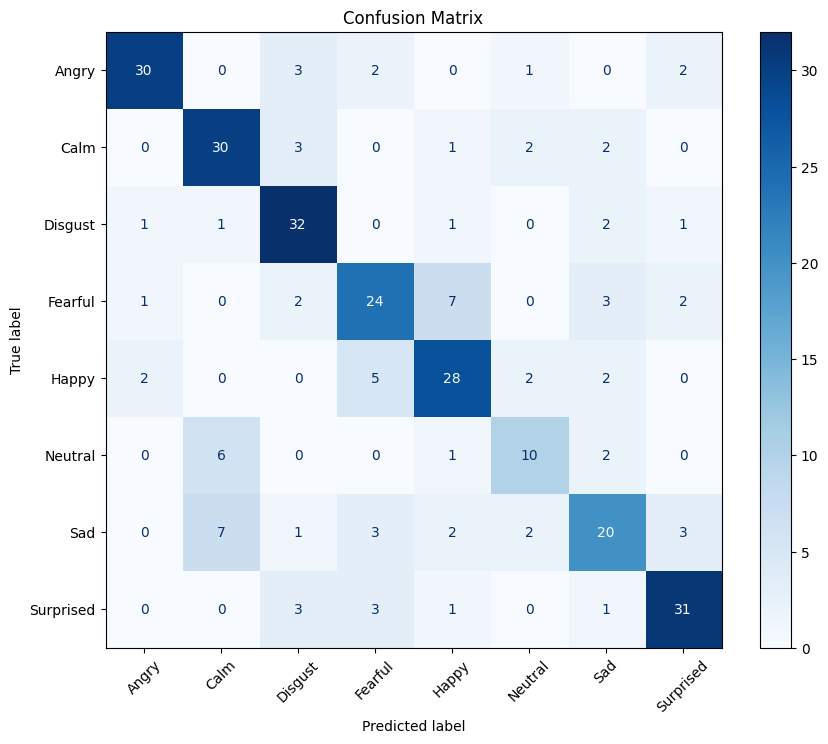

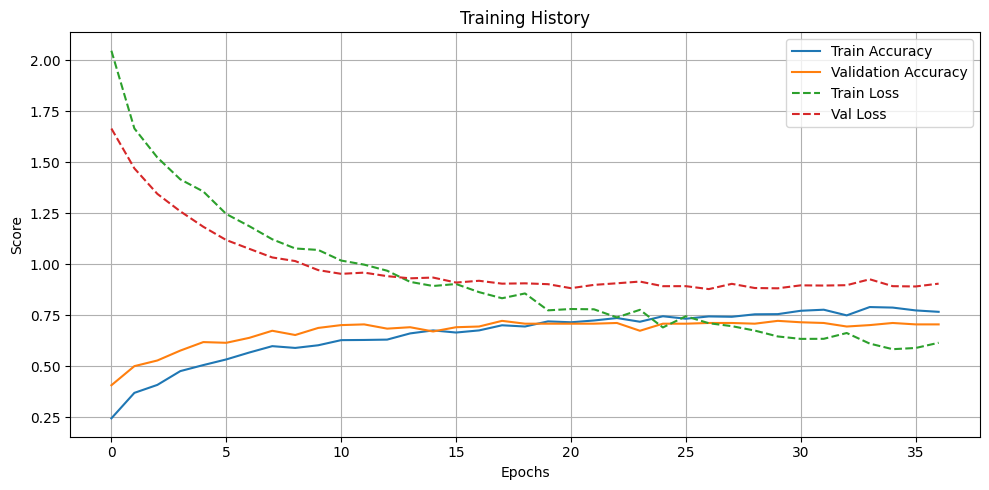

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Load and normalize per actor ---
# Extract actor from filename or path
df_combined['Actor'] = df_combined['File'].str.extract(r'(\d+)\.wav$')

# Normalize features within each actor group
numeric_features = df_combined.select_dtypes(include=np.number).columns
df_combined[numeric_features] = df_combined.groupby('Actor')[numeric_features].transform(
    lambda x: (x - x.mean()) / x.std()
)

# --- 2. Split features and labels ---
X = df_combined.drop(columns=['File', 'Emotion', 'Root', 'Path', 'Actor'])  # exclude non-features
y = df_combined['Emotion']

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize across the dataset ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 6. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))

# --- 7. Define MLP model with dropout ---
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(dummy_y_train.shape[1], activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 8. Train with early stopping and class weights ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 9. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 10. Classification Report and Confusion Matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

class_names = encoder.classes_

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 11. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
# --- 1. Load CSV file ---
file_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/RAVDESS_eGeMAPS._features.csv"
df_combined = pd.read_csv(file_path)

In [ ]:
df_combined

,File,Emotion,Root,Path,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,03-01-05-02-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-02-02-0...,42.944070,0.107373,37.567955,43.100674,47.403534,9.835579,...,0.051557,0.021143,0.069896,2.072539,1.574803,0.205000,0.137447,0.406667,0.437328,-20.424952
1,03-01-03-01-01-02-10.wav,Happy,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-03-01-01-0...,40.652424,0.064248,38.464455,41.441025,42.604507,4.140053,...,0.031080,0.024892,0.026161,2.312139,1.173021,0.297500,0.193827,0.426000,0.451291,-30.586110
2,03-01-05-01-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-01-02-0...,34.737854,0.060301,33.147250,34.287140,36.573315,3.426064,...,0.030052,0.025025,0.017507,2.933985,1.237624,0.306000,0.168950,0.400000,0.430194,-33.042236
3,03-01-05-02-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-02-02-0...,40.242640,0.100236,37.839900,40.133690,44.284770,6.444870,...,0.038861,0.023983,0.025719,2.427185,0.982801,0.445000,0.196787,0.547500,0.458714,-20.703802
4,03-01-05-01-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,/content/RAVDESS_ORG/Actor_10/03-01-05-01-02-0...,34.970997,0.050141,33.830240,34.376793,36.545563,2.715324,...,0.037800,0.023268,0.021745,2.669903,1.481482,0.263333,0.285871,0.334286,0.422505,-32.660904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,03-01-07-02-02-01-03.wav,Disgust,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-07-02-02-0...,28.487143,0.103432,24.934540,29.178436,30.761175,5.826635,...,0.049886,0.010685,0.022899,3.141361,2.122016,0.112500,0.087142,0.267000,0.252945,-36.981170
1436,03-01-03-02-01-02-03.wav,Happy,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-03-02-01-0...,37.864285,0.102870,36.379803,38.597137,40.198093,3.818291,...,0.040303,0.027253,0.014143,1.594533,1.152074,0.424000,0.207711,0.351667,0.432412,-24.918018
1437,03-01-06-01-01-01-03.wav,Fearful,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-06-01-01-0...,28.953190,0.094515,26.459208,29.784376,31.390781,4.931574,...,0.052018,0.024537,0.015083,2.688172,2.452316,0.088889,0.045325,0.268000,0.365508,-43.789917
1438,03-01-08-01-01-01-03.wav,Surprised,/content/RAVDESS_ORG/Actor_03,/content/RAVDESS_ORG/Actor_03/03-01-08-01-01-0...,36.582073,0.095529,35.000317,36.121796,39.664997,4.664681,...,0.077950,0.037106,0.029000,2.484472,1.261830,0.217500,0.192792,0.550000,0.480260,-39.159958


## MLP eGeMap PCA

Epoch 1/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1474 - loss: 2.3661 - val_accuracy: 0.2882 - val_loss: 1.9591
Epoch 2/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2557 - loss: 1.9192 - val_accuracy: 0.3646 - val_loss: 1.8202
Epoch 3/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3145 - loss: 1.7661 - val_accuracy: 0.3924 - val_loss: 1.7379
Epoch 4/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4006 - loss: 1.6183 - val_accuracy: 0.4236 - val_loss: 1.6787
Epoch 5/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3958 - loss: 1.5851 - val_accuracy: 0.4444 - val_loss: 1.6187
Epoch 6/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4300 - loss: 1.5174 - val_accuracy: 0.4444 - val_loss: 1.5895
Epoch 7/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4838 - loss: 1.4740 - val_accuracy: 0.4618 - val_loss: 1.5451
Epoch 8/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4932 - loss: 1.3783 - val_a

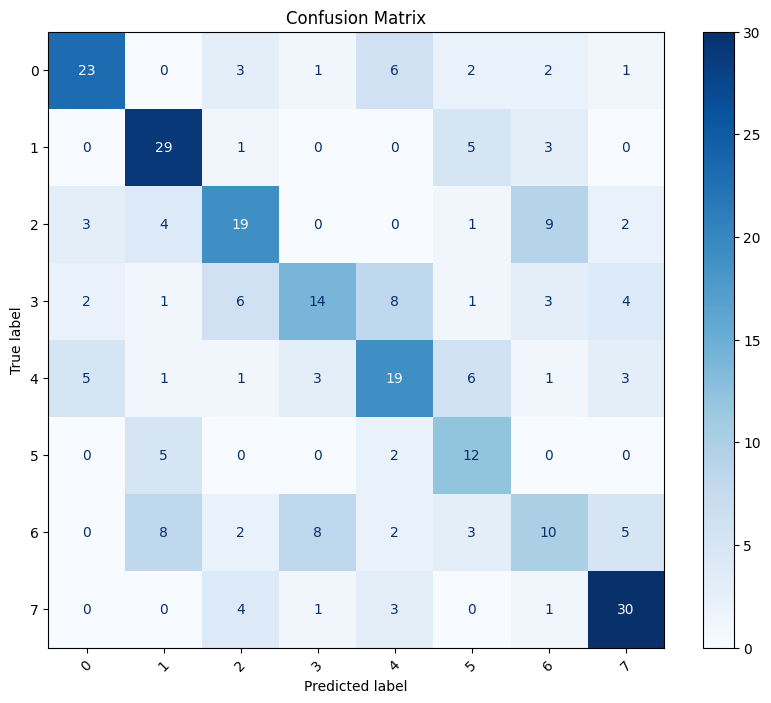

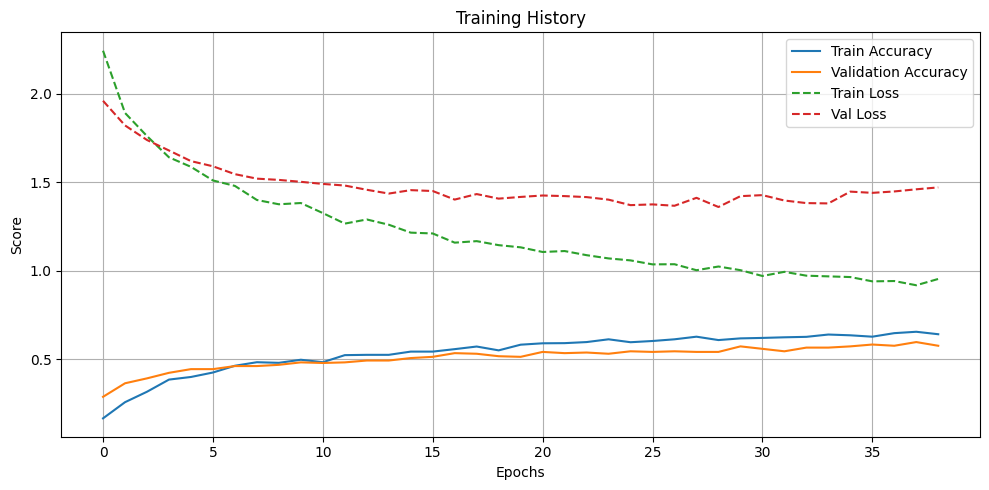

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping



# --- 2. Split features and labels ---
X = df_combined.drop(columns=[ 'Emotion'])  # exclude non-features
y = df_combined['Emotion']

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize across the dataset ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Apply PCA ---
pca = PCA(n_components=0.95)  # Keep 95% of variance
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

# --- 6. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 7. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))


# --- 8. Define MLP model with dropout ---
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(dummy_y_train.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 9. Train with early stopping and class weights ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 10. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 11. Classification Report and Confusion Matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

class_names = encoder.classes_
class_names = encoder.classes_.astype(str)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 12. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


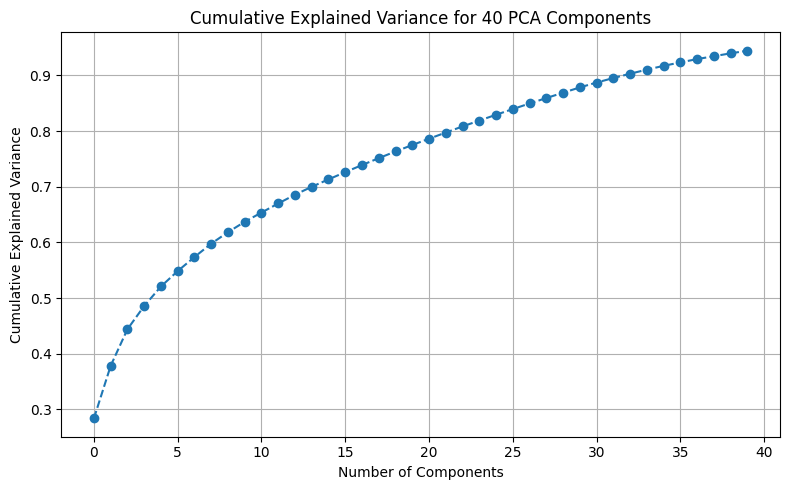

Epoch 1/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1604 - loss: 2.4053 - val_accuracy: 0.2986 - val_loss: 1.9059
Epoch 2/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2828 - loss: 1.8900 - val_accuracy: 0.3368 - val_loss: 1.7717
Epoch 3/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2969 - loss: 1.7729 - val_accuracy: 0.3819 - val_loss: 1.6990
Epoch 4/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3533 - loss: 1.6819 - val_accuracy: 0.4167 - val_loss: 1.6528
Epoch 5/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3748 - loss: 1.5801 - val_accuracy: 0.4236 - val_loss: 1.5659
Epoch 6/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4357 - loss: 1.5120 - val_accuracy: 0.4410 - val_loss: 1.5210
Epoch 7/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4255 - loss: 1.4723 - val_accuracy: 0.4688 - val_loss: 1.4821
Epoch 8/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4754 - loss: 1.3764 - val_a

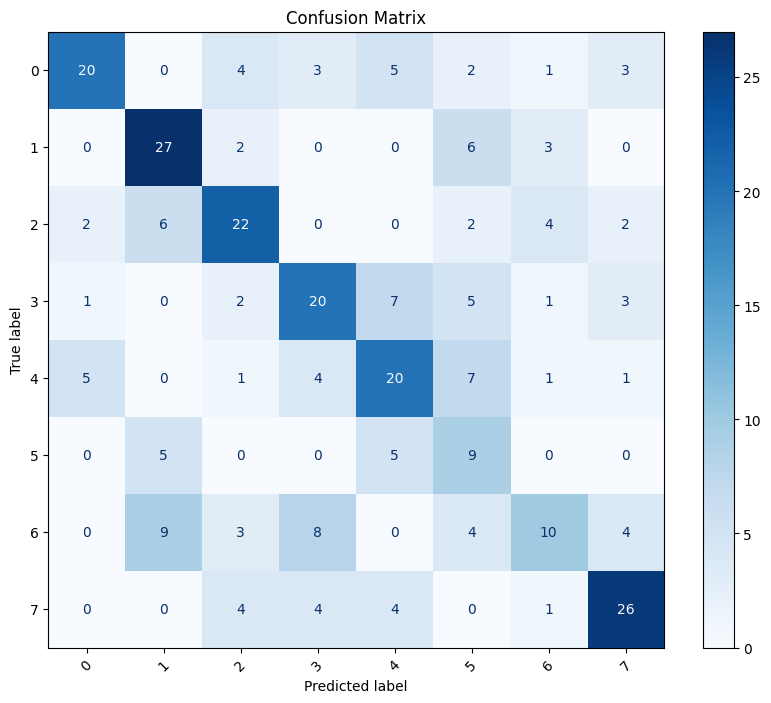

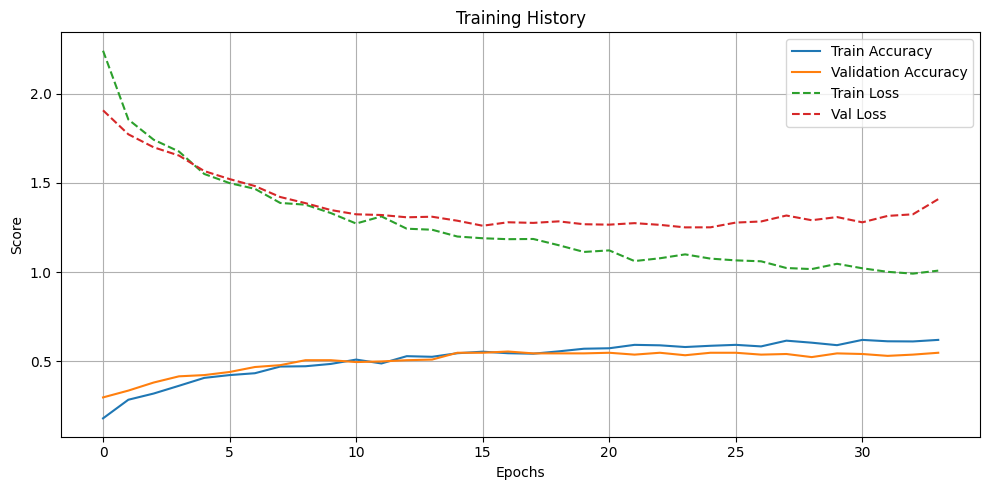

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping



# --- 2. Split features and labels ---
X = df_combined.drop(columns=['Emotion'])  # exclude label
y = df_combined['Emotion']

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize the data ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Apply PCA with a fixed number of components ---
n_components = 40  # You can adjust this
pca = PCA(n_components=n_components)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title(f'Cumulative Explained Variance for {n_components} PCA Components')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 6. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 7. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))

# --- 8. Define MLP model with dropout ---
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(dummy_y_train.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 9. Train with early stopping and class weights ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 10. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 11. Classification Report and Confusion Matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

class_names = encoder.classes_.astype(str)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 12. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## MLP MFCC

In [ ]:
import pandas as pd
import numpy as np
import librosa
import soundfile
from tqdm import tqdm

def extract_feature(file_name, mfcc=True):
    try:
        with soundfile.SoundFile(file_name) as sound_file:
            X = sound_file.read(dtype="float32")
            sample_rate = sound_file.samplerate
            result = np.array([])
            if mfcc:
                mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
                result = np.hstack((result, mfccs))
        return result
    except Exception as e:
        print(f"Error in {file_name}: {e}")
        return None

# Initialize list to hold all features
features = []
labels = []

# Iterate through the dataframe to extract features
for index, row in tqdm(df_docr.iterrows(), total=len(df_docr)):
    file_path = f"{row['Root']}/{row['File']}"
    try:
       # feat = extract_feature(file_path, mfcc=True, chroma=True, mel=True)
        feat = extract_feature(file_path, mfcc=True)
        features.append(feat)
        labels.append(row["Emotion"])
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create DataFrame with extracted features
features_df = pd.DataFrame(features)
#["Emotion"] = labels


100%|██████████| 1440/1440 [00:53<00:00, 26.83it/s]


In [ ]:
features_df

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-379.596100,31.460497,-16.444790,-3.235934,-16.580772,-9.356936,-12.996932,-15.875826,-7.940342,-6.719835,...,1.133169,0.005014,0.175461,0.150967,-0.520659,-1.758919,0.717872,1.645961,0.507037,0.219246
1,-484.353149,40.566769,-13.654327,8.229918,-6.208307,-9.098079,-15.268682,-13.475571,-0.313624,-8.770497,...,-0.434593,0.096358,-1.248114,-0.475715,-0.449630,-2.005617,-1.035731,0.884212,0.207163,-1.562404
2,-489.723022,54.466064,-11.889915,3.865436,-5.658755,-6.735503,-20.016441,-10.727929,-0.976252,-7.056825,...,5.837626,7.928489,5.810400,6.063447,3.718822,4.957030,1.527992,2.247018,-0.277264,0.176902
3,-373.605225,24.902893,-19.829201,-3.483590,-19.377636,-8.968192,-15.130720,-13.976008,-8.275378,-7.607152,...,0.163479,-0.741921,0.961123,-0.732815,2.330867,-1.573007,2.319536,-0.563757,-4.444435,-3.000044
4,-489.904205,55.430775,-13.937671,9.932542,-10.484921,-3.710706,-23.655788,-6.521538,-1.604032,-6.613357,...,7.788198,9.110920,6.534425,3.531838,1.670152,0.560981,0.525632,2.934977,0.766532,-0.336677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-477.182251,60.097813,-3.156418,2.190845,-8.999051,-12.792125,-9.862238,-3.632188,-16.775290,-3.043611,...,-2.107504,-2.706825,-2.136084,-5.044012,-6.184338,-2.626507,-0.997751,0.031672,0.395042,-0.457119
1436,-382.501648,36.131561,-18.769442,-7.235864,-11.513783,-4.762020,-21.248560,-9.019439,-20.749802,4.458447,...,1.582525,5.130415,2.970831,0.483035,-0.158035,0.877907,0.272806,0.788079,-0.200637,0.604530
1437,-560.667419,57.939842,-3.506342,13.660791,-0.224094,-4.262780,-22.778538,-3.814871,-6.506873,-3.829307,...,-2.603539,-0.046734,-1.606569,-1.598650,-3.055362,1.058725,1.520138,3.003290,1.703615,-0.152023
1438,-548.329102,49.164619,-17.112446,1.104691,-8.544814,-8.031075,-21.285004,-6.784071,-13.021824,-1.119826,...,2.184272,1.192860,-2.811975,-2.826205,-2.092955,1.262190,1.481592,0.177790,-1.141029,-0.274771


In [ ]:
df_combined2 = pd.concat([df_docr.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)
df_combined2


,File,Emotion,Root,0,1,2,3,4,5,6,...,30,31,32,33,34,35,36,37,38,39
0,03-01-05-02-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-379.596100,31.460497,-16.444790,-3.235934,-16.580772,-9.356936,-12.996932,...,1.133169,0.005014,0.175461,0.150967,-0.520659,-1.758919,0.717872,1.645961,0.507037,0.219246
1,03-01-03-01-01-02-10.wav,Happy,/content/RAVDESS_ORG/Actor_10,-484.353149,40.566769,-13.654327,8.229918,-6.208307,-9.098079,-15.268682,...,-0.434593,0.096358,-1.248114,-0.475715,-0.449630,-2.005617,-1.035731,0.884212,0.207163,-1.562404
2,03-01-05-01-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-489.723022,54.466064,-11.889915,3.865436,-5.658755,-6.735503,-20.016441,...,5.837626,7.928489,5.810400,6.063447,3.718822,4.957030,1.527992,2.247018,-0.277264,0.176902
3,03-01-05-02-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-373.605225,24.902893,-19.829201,-3.483590,-19.377636,-8.968192,-15.130720,...,0.163479,-0.741921,0.961123,-0.732815,2.330867,-1.573007,2.319536,-0.563757,-4.444435,-3.000044
4,03-01-05-01-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-489.904205,55.430775,-13.937671,9.932542,-10.484921,-3.710706,-23.655788,...,7.788198,9.110920,6.534425,3.531838,1.670152,0.560981,0.525632,2.934977,0.766532,-0.336677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,03-01-07-02-02-01-03.wav,Disgust,/content/RAVDESS_ORG/Actor_03,-477.182251,60.097813,-3.156418,2.190845,-8.999051,-12.792125,-9.862238,...,-2.107504,-2.706825,-2.136084,-5.044012,-6.184338,-2.626507,-0.997751,0.031672,0.395042,-0.457119
1436,03-01-03-02-01-02-03.wav,Happy,/content/RAVDESS_ORG/Actor_03,-382.501648,36.131561,-18.769442,-7.235864,-11.513783,-4.762020,-21.248560,...,1.582525,5.130415,2.970831,0.483035,-0.158035,0.877907,0.272806,0.788079,-0.200637,0.604530
1437,03-01-06-01-01-01-03.wav,Fearful,/content/RAVDESS_ORG/Actor_03,-560.667419,57.939842,-3.506342,13.660791,-0.224094,-4.262780,-22.778538,...,-2.603539,-0.046734,-1.606569,-1.598650,-3.055362,1.058725,1.520138,3.003290,1.703615,-0.152023
1438,03-01-08-01-01-01-03.wav,Surprised,/content/RAVDESS_ORG/Actor_03,-548.329102,49.164619,-17.112446,1.104691,-8.544814,-8.031075,-21.285004,...,2.184272,1.192860,-2.811975,-2.826205,-2.092955,1.262190,1.481592,0.177790,-1.141029,-0.274771


In [ ]:

# Save to CSV
df_combined2.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/RAVDESS_MFCC_features.csv", index=False)

In [ ]:
import pandas as pd
# --- 1. Load CSV file ---
file_path2 = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/RAVDESS_MFCC_features.csv"
df_combined2 = pd.read_csv(file_path2)

In [ ]:
df_combined2

,File,Emotion,Root,0,1,2,3,4,5,6,...,30,31,32,33,34,35,36,37,38,39
0,03-01-05-02-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-379.596100,31.460497,-16.444790,-3.235934,-16.580772,-9.356936,-12.996932,...,1.133169,0.005014,0.175461,0.150967,-0.520659,-1.758919,0.717872,1.645961,0.507037,0.219246
1,03-01-03-01-01-02-10.wav,Happy,/content/RAVDESS_ORG/Actor_10,-484.353149,40.566769,-13.654327,8.229918,-6.208307,-9.098079,-15.268682,...,-0.434593,0.096358,-1.248114,-0.475715,-0.449630,-2.005617,-1.035731,0.884212,0.207163,-1.562404
2,03-01-05-01-02-01-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-489.723022,54.466064,-11.889915,3.865436,-5.658755,-6.735503,-20.016441,...,5.837626,7.928489,5.810400,6.063447,3.718822,4.957030,1.527992,2.247018,-0.277264,0.176902
3,03-01-05-02-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-373.605225,24.902893,-19.829201,-3.483590,-19.377636,-8.968192,-15.130720,...,0.163479,-0.741921,0.961123,-0.732815,2.330867,-1.573007,2.319536,-0.563757,-4.444435,-3.000044
4,03-01-05-01-02-02-10.wav,Angry,/content/RAVDESS_ORG/Actor_10,-489.904205,55.430775,-13.937671,9.932542,-10.484921,-3.710706,-23.655788,...,7.788198,9.110920,6.534425,3.531838,1.670152,0.560981,0.525632,2.934977,0.766532,-0.336677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,03-01-07-02-02-01-03.wav,Disgust,/content/RAVDESS_ORG/Actor_03,-477.182251,60.097813,-3.156418,2.190845,-8.999051,-12.792125,-9.862238,...,-2.107504,-2.706825,-2.136084,-5.044012,-6.184338,-2.626507,-0.997751,0.031672,0.395042,-0.457119
1436,03-01-03-02-01-02-03.wav,Happy,/content/RAVDESS_ORG/Actor_03,-382.501648,36.131561,-18.769442,-7.235864,-11.513783,-4.762020,-21.248560,...,1.582525,5.130415,2.970831,0.483035,-0.158035,0.877907,0.272806,0.788079,-0.200637,0.604530
1437,03-01-06-01-01-01-03.wav,Fearful,/content/RAVDESS_ORG/Actor_03,-560.667419,57.939842,-3.506342,13.660791,-0.224094,-4.262780,-22.778538,...,-2.603539,-0.046734,-1.606569,-1.598650,-3.055362,1.058725,1.520138,3.003290,1.703615,-0.152023
1438,03-01-08-01-01-01-03.wav,Surprised,/content/RAVDESS_ORG/Actor_03,-548.329102,49.164619,-17.112446,1.104691,-8.544814,-8.031075,-21.285004,...,2.184272,1.192860,-2.811975,-2.826205,-2.092955,1.262190,1.481592,0.177790,-1.141029,-0.274771


Epoch 1/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1423 - loss: 2.2517 - val_accuracy: 0.2743 - val_loss: 1.8981
Epoch 2/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2689 - loss: 1.8842 - val_accuracy: 0.3368 - val_loss: 1.8010
Epoch 3/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2662 - loss: 1.7880 - val_accuracy: 0.3472 - val_loss: 1.7275
Epoch 4/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3275 - loss: 1.7043 - val_accuracy: 0.4062 - val_loss: 1.6530
Epoch 5/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3830 - loss: 1.6043 - val_accuracy: 0.4444 - val_loss: 1.5805
Epoch 6/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4061 - loss: 1.5211 - val_accuracy: 0.4514 - val_loss: 1.5310
Epoch 7/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4277 - loss: 1.4877 - val_accuracy: 0.4688 - val_loss: 1.4726
Epoch 8/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4093 - loss: 1.4726 - val

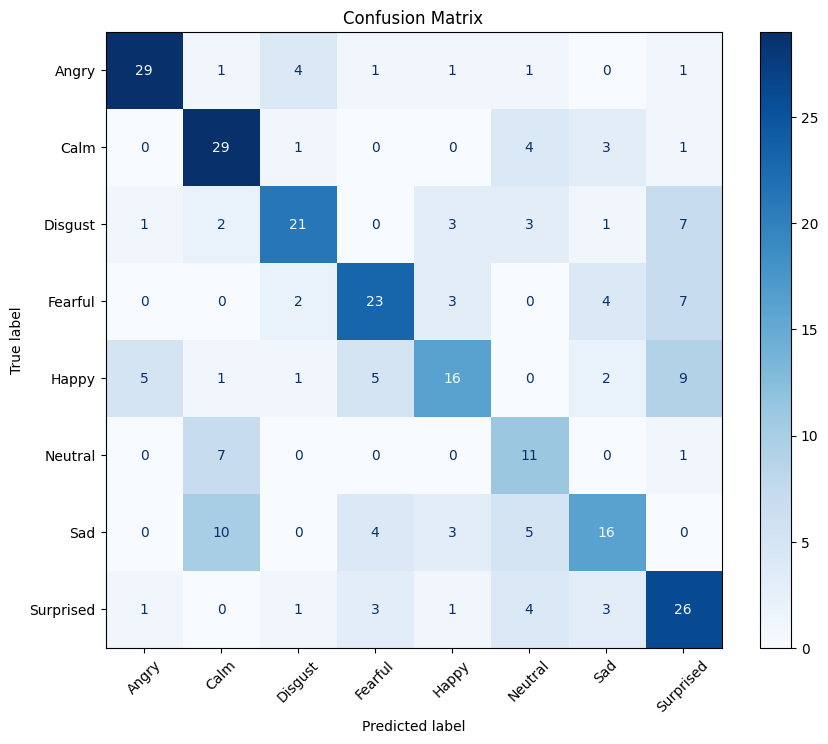

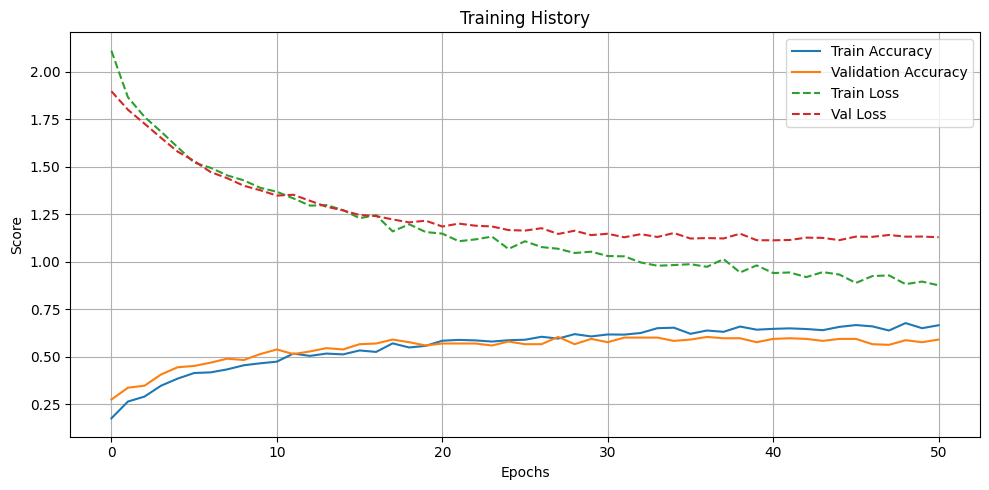

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Load and normalize per actor ---
# Extract actor from filename or path
df_combined2['Actor'] = df_combined2['File'].str.extract(r'(\d+)\.wav$')

# Normalize features within each actor group
numeric_features = df_combined2.select_dtypes(include=np.number).columns
df_combined2[numeric_features] = df_combined2.groupby('Actor')[numeric_features].transform(
    lambda x: (x - x.mean()) / x.std()
)

# --- 2. Split features and labels ---
X = df_combined2.drop(columns=['File', 'Emotion', 'Root'])  # exclude non-features
y = df_combined2['Emotion']

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize across the dataset ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 6. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))

# --- 7. Define MLP model with dropout ---
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(dummy_y_train.shape[1], activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 8. Train with early stopping and class weights ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 9. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 10. Classification Report and Confusion Matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

class_names = encoder.classes_

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 11. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# CNN

In [ ]:
import pandas as pd
# --- 1. Load CSV file ---
file_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/RAVDESS_eGeMAPS._features.csv"
df_combined = pd.read_csv(file_path)

In [ ]:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization,LSTM
#from keras.utils import np_utils, to_categorical
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Encode 'Emotion' column to numerical values
le = LabelEncoder()
df_combined['Emotion'] = le.fit_transform(df_combined['Emotion'])

# Drop unwanted columns
columns_to_exclude = ['File', 'Root', 'Path']
df_features = df_combined.drop(columns=columns_to_exclude, errors='ignore')

# Reset index if needed
df_features.reset_index(drop=True, inplace=True)

# Separate features and target variable
X = df_features.drop(columns=['Emotion'])
y = df_features['Emotion']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import numpy as np



# --- 2. Split features and labels ---
X = df_combined.drop(columns=['Emotion'])  # Feature columns
y = df_combined['Emotion']                 # Label column

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize the features ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Reshape input for Conv1D (add channel dimension) ---
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# --- 6. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode the labels
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 7. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(encoded_y_train),
    y=encoded_y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))

print("x_train:", x_train.shape)
print("dummy_y_train:", dummy_y_train.shape)


In [ ]:
print("x_train:", x_train.shape)  # Should be (samples, 88, 1) or similar
print("dummy_y_train:", dummy_y_train.shape)  # Should be (samples, 8)

x_train: (1152, 88, 1)
dummy_y_train: (1152, 8)


## Conv1D

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model=Sequential()

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
model.add(Dropout(0.2))

model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))


model.add(Dense(8, activation='softmax'))
model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 88, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 88, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 44, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 44, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 22, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 22, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 11, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,872 (1.47 MB)

 Trainable params: 383,656 (1.46 MB)

 Non-trainable params: 1,216 (4.75 KB)

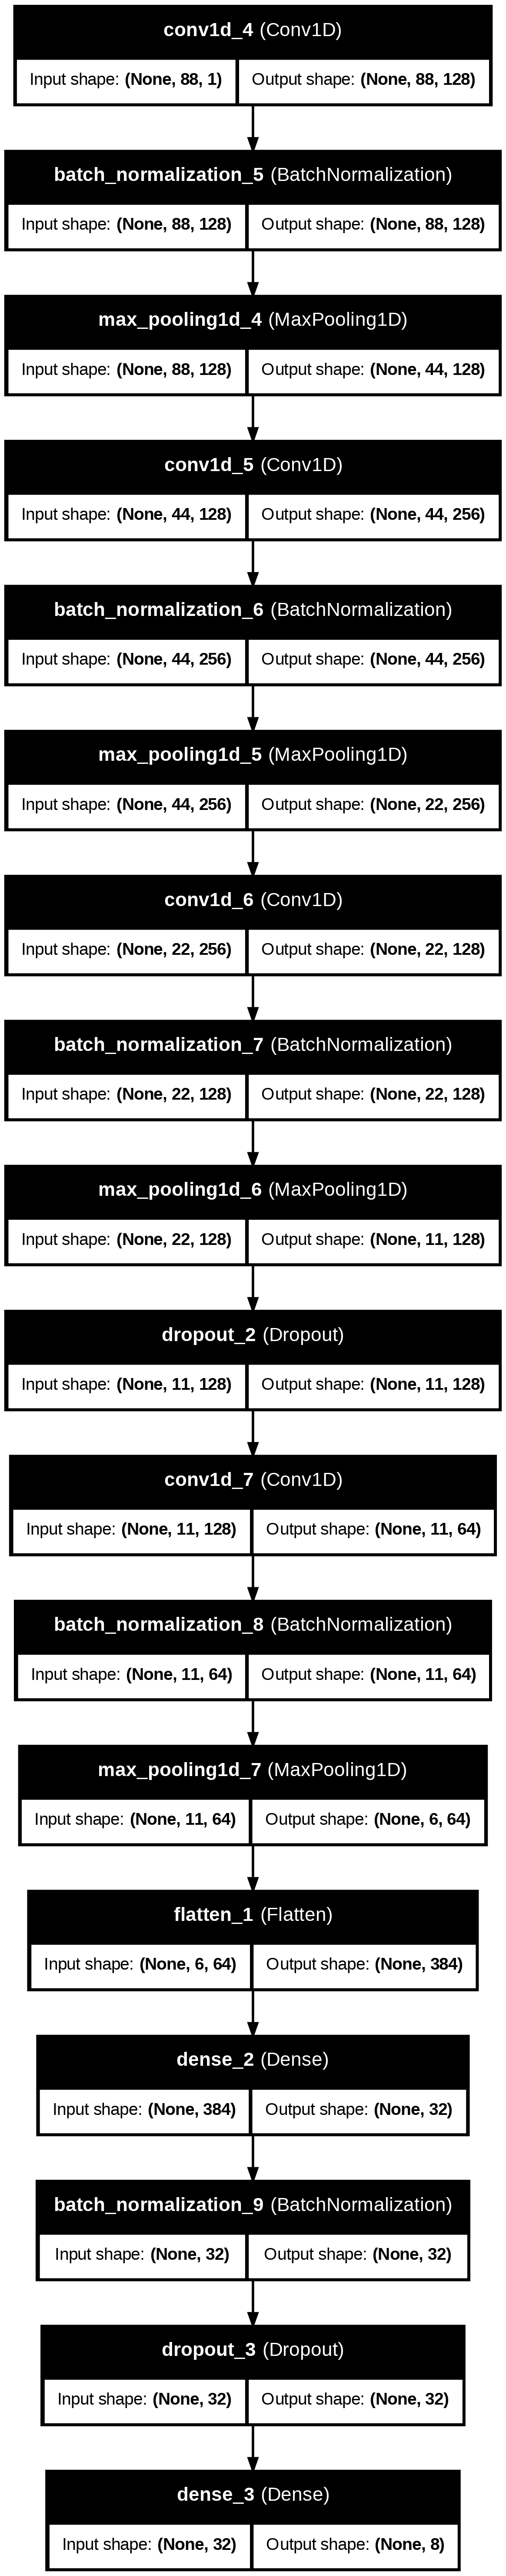

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)
callbacks=[learning_rate_reduction]

Epoch 1/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.1900 - loss: 2.3416 - val_accuracy: 0.1389 - val_loss: 2.4426
Epoch 2/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.2215 - loss: 2.1180 - val_accuracy: 0.1632 - val_loss: 2.5291
Epoch 3/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2927 - loss: 1.8760 - val_accuracy: 0.1840 - val_loss: 2.5032
Epoch 4/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.3069 - loss: 1.7938 - val_accuracy: 0.2639 - val_loss: 2.1180
Epoch 5/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.3553 - loss: 1.7348 - val_accuracy: 0.3021 - val_loss: 1.9203
Epoch 6/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.3583 - loss: 1.6114 - val_accuracy: 0.3403 - val_loss: 1.8018
Epoch 7/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.3873 - loss: 1.6166 - val_accuracy: 0.3646 - val_loss: 2.0833
Epoch 8/150
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.3552 - loss: 1.6130 -

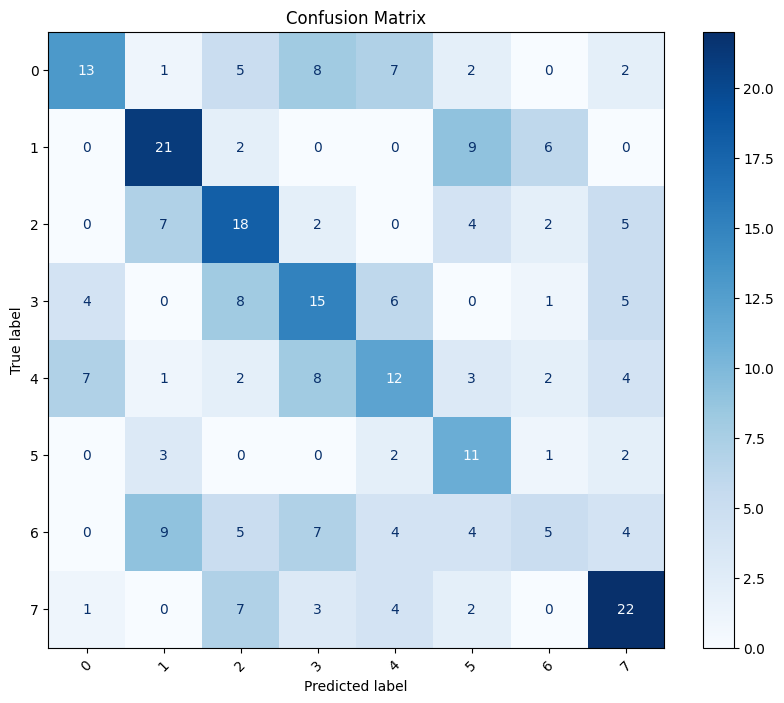

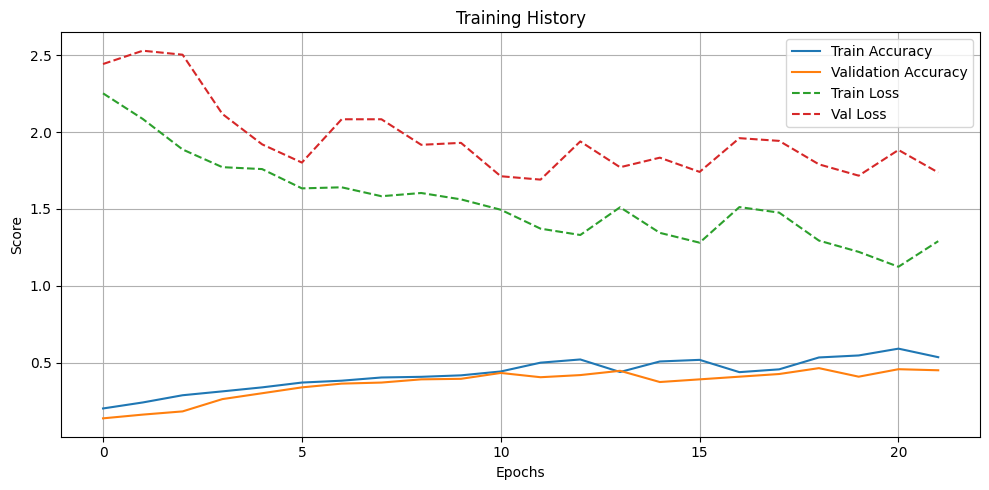

In [ ]:
# --- 8. Train with early stopping and class weights ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 9. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 10. Classification Report and Confusion Matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

# Ensure class labels are strings for report and confusion matrix
class_names = [str(cls) for cls in encoder.classes_]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix with string labels
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 11. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Augmented Data

In [ ]:
!unzip '/content/drive/MyDrive/SERDATABASES/AUG_RAVDESS.zip' -d '/content/RAVDESS_AUG'

Archive:  /content/drive/MyDrive/SERDATABASES/AUG_RAVDESS.zip
  inflating: /content/RAVDESS_AUG/14-1140-03-01-08-02-02-02-24.wav  
  inflating: /content/RAVDESS_AUG/11-1-03-01-01-01-01-01-06.wav  
  inflating: /content/RAVDESS_AUG/11-2-03-01-01-01-01-02-06.wav  
  inflating: /content/RAVDESS_AUG/11-3-03-01-01-01-02-01-06.wav  
  inflating: /content/RAVDESS_AUG/11-4-03-01-01-01-02-02-06.wav  
  inflating: /content/RAVDESS_AUG/11-5-03-01-02-01-01-01-06.wav  
  inflating: /content/RAVDESS_AUG/11-6-03-01-02-01-01-02-06.wav  
  inflating: /content/RAVDESS_AUG/11-7-03-01-02-01-02-01-06.wav  
  inflating: /content/RAVDESS_AUG/11-8-03-01-02-01-02-02-06.wav  
  inflating: /content/RAVDESS_AUG/11-9-03-01-02-02-01-01-06.wav  
  inflating: /content/RAVDESS_AUG/11-10-03-01-02-02-01-02-06.wav  
  inflating: /content/RAVDESS_AUG/11-11-03-01-02-02-02-01-06.wav  
  inflating: /content/RAVDESS_AUG/11-12-03-01-02-02-02-02-06.wav  
  inflating: /content/RAVDESS_AUG/11-13-03-01-03-01-01-01-06.wav  
  infla

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

X_Aug = []
y_Aug = []
z_Aug = []
for file in glob.glob('/content/RAVDESS_AUG/*.wav'):

    basename = os.path.basename(file)
    rootname = os.path.dirname(file)
    emotion = basename.split('-')[4]
    X_Aug.append(basename)
    y_Aug.append(emotion)
    z_Aug.append(rootname)
a_Aug = np.array(X_Aug)
b_Aug = np.array(y_Aug)
c_Aug = np.array(z_Aug)
doc_Aug = np.column_stack((a_Aug, b_Aug, c_Aug))
df_doc_Aug = pd.DataFrame(doc_Aug, columns = ['File','Emotion', 'Root'])

In [ ]:
df_doc_Aug

,File,Emotion,Root
0,11-379-03-01-03-02-02-01-12.wav,03,/content/RAVDESS_AUG
1,13-678-03-01-03-02-01-02-17.wav,03,/content/RAVDESS_AUG
2,14-697-03-01-06-01-01-01-17.wav,06,/content/RAVDESS_AUG
3,12-1025-03-01-02-01-01-01-23.wav,02,/content/RAVDESS_AUG
4,12-154-03-01-05-02-01-02-08.wav,05,/content/RAVDESS_AUG
...,...,...,...
4555,14-1121-03-01-06-02-01-01-24.wav,06,/content/RAVDESS_AUG
4556,12-3-03-01-01-01-02-01-06.wav,01,/content/RAVDESS_AUG
4557,11-432-03-01-02-02-02-02-13.wav,02,/content/RAVDESS_AUG
4558,11-316-03-01-03-01-02-02-11.wav,03,/content/RAVDESS_AUG


In [ ]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.0/996.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 17.1 MB/s eta 0:00:00


In [ ]:
import opensmile
import pandas as pd
import os
from tqdm import tqdm  # progress bar

# Initialize OpenSMILE extractor
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

# Assuming your dataframe looks like this:
# df_docr has columns: "File", "Emotion", "Root"
# We'll compute full path to the file
df_doc_Aug["Path"] = df_doc_Aug.apply(lambda row: os.path.join(row["Root"], row["File"]), axis=1)

# Create a list to store all features
all_features = []

# Iterate through each audio file path and extract features
for path in tqdm(df_doc_Aug["Path"], desc="Extracting features"):
    try:
        feats = smile.process_file(path)
        # feats is a DataFrame with 1 row (index = path), we reset index to clean it
        feats.reset_index(drop=True, inplace=True)
        all_features.append(feats.iloc[0])
    except Exception as e:
        print(f"Error processing {path}: {e}")
        all_features.append(pd.Series([None]*88, index=smile.feature_names))  # fill with NaN

# Convert all features into a DataFrame
df_features = pd.DataFrame(all_features)


Extracting features: 100%|██████████| 4560/4560 [18:44<00:00,  4.05it/s]


In [ ]:
df_features

,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,38.905033,0.091265,37.797726,39.689980,41.622688,3.824963,43.138298,21.716740,34.886124,26.790474,...,0.021230,0.002956,0.087659,1.804124,1.044386,0.347500,0.202531,0.470000,0.473117,-33.050503
0,38.304432,0.142300,35.072639,38.785248,42.334209,7.261570,58.333336,28.486038,80.047287,94.940758,...,-0.018445,0.008135,0.084763,1.960784,1.736973,0.175714,0.083471,0.331250,0.494379,-25.157513
0,30.317131,0.110858,27.415815,28.480635,34.136734,6.720919,17.519499,7.831558,103.652786,90.655891,...,-0.026291,0.014928,0.011247,1.449275,1.176471,0.257500,0.261761,0.567500,0.512366,-38.207733
0,27.037003,0.104649,24.721802,26.227253,29.451542,4.729740,20.070581,10.580526,15.709426,2.637446,...,0.006650,0.005508,0.002587,1.012146,1.022495,0.306000,0.087544,0.541667,0.536079,-50.002537
0,42.740055,0.103469,40.645222,43.064568,46.791767,6.146545,123.399612,123.972450,57.134296,77.672546,...,0.012463,0.004766,0.043072,1.279318,1.293103,0.273333,0.137800,0.476667,0.597653,-24.294119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,52.950798,0.058752,50.656742,53.947727,55.411533,4.754791,34.120930,12.730889,19.674810,15.779518,...,0.073699,0.001776,0.005290,1.574803,0.265957,1.740000,0.000000,0.995000,0.005000,-28.526997
0,36.458992,0.065941,34.461220,36.229794,38.592079,4.130859,7.694566,3.785384,-3.255896,10.788122,...,0.020768,0.001381,0.002907,1.182033,1.674641,0.167143,0.098375,0.352500,0.484116,-52.075024
0,24.068619,0.083231,22.087950,23.835627,26.276535,4.188585,55.914886,50.899921,16.631817,5.399235,...,0.035760,0.004545,0.017071,1.993356,1.351351,0.217500,0.110764,0.400000,0.445152,-47.597874
0,27.636768,0.123210,24.110992,26.985666,31.601067,7.490074,21.763632,7.035800,10.517553,13.357509,...,0.028439,0.004423,0.035434,1.246106,1.265823,0.232500,0.133112,0.428000,0.434898,-41.734173


In [ ]:
df_combined = pd.concat([df_doc_Aug.reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)


In [ ]:
df_combined

,File,Emotion,Root,Path,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,11-379-03-01-03-02-02-01-12.wav,03,/content/RAVDESS_AUG,/content/RAVDESS_AUG/11-379-03-01-03-02-02-01-...,38.905033,0.091265,37.797726,39.689980,41.622688,3.824963,...,0.021230,0.002956,0.087659,1.804124,1.044386,0.347500,0.202531,0.470000,0.473117,-33.050503
1,13-678-03-01-03-02-01-02-17.wav,03,/content/RAVDESS_AUG,/content/RAVDESS_AUG/13-678-03-01-03-02-01-02-...,38.304432,0.142300,35.072639,38.785248,42.334209,7.261570,...,-0.018445,0.008135,0.084763,1.960784,1.736973,0.175714,0.083471,0.331250,0.494379,-25.157513
2,14-697-03-01-06-01-01-01-17.wav,06,/content/RAVDESS_AUG,/content/RAVDESS_AUG/14-697-03-01-06-01-01-01-...,30.317131,0.110858,27.415815,28.480635,34.136734,6.720919,...,-0.026291,0.014928,0.011247,1.449275,1.176471,0.257500,0.261761,0.567500,0.512366,-38.207733
3,12-1025-03-01-02-01-01-01-23.wav,02,/content/RAVDESS_AUG,/content/RAVDESS_AUG/12-1025-03-01-02-01-01-01...,27.037003,0.104649,24.721802,26.227253,29.451542,4.729740,...,0.006650,0.005508,0.002587,1.012146,1.022495,0.306000,0.087544,0.541667,0.536079,-50.002537
4,12-154-03-01-05-02-01-02-08.wav,05,/content/RAVDESS_AUG,/content/RAVDESS_AUG/12-154-03-01-05-02-01-02-...,42.740055,0.103469,40.645222,43.064568,46.791767,6.146545,...,0.012463,0.004766,0.043072,1.279318,1.293103,0.273333,0.137800,0.476667,0.597653,-24.294119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,14-1121-03-01-06-02-01-01-24.wav,06,/content/RAVDESS_AUG,/content/RAVDESS_AUG/14-1121-03-01-06-02-01-01...,52.950798,0.058752,50.656742,53.947727,55.411533,4.754791,...,0.073699,0.001776,0.005290,1.574803,0.265957,1.740000,0.000000,0.995000,0.005000,-28.526997
4556,12-3-03-01-01-01-02-01-06.wav,01,/content/RAVDESS_AUG,/content/RAVDESS_AUG/12-3-03-01-01-01-02-01-06...,36.458992,0.065941,34.461220,36.229794,38.592079,4.130859,...,0.020768,0.001381,0.002907,1.182033,1.674641,0.167143,0.098375,0.352500,0.484116,-52.075024
4557,11-432-03-01-02-02-02-02-13.wav,02,/content/RAVDESS_AUG,/content/RAVDESS_AUG/11-432-03-01-02-02-02-02-...,24.068619,0.083231,22.087950,23.835627,26.276535,4.188585,...,0.035760,0.004545,0.017071,1.993356,1.351351,0.217500,0.110764,0.400000,0.445152,-47.597874
4558,11-316-03-01-03-01-02-02-11.wav,03,/content/RAVDESS_AUG,/content/RAVDESS_AUG/11-316-03-01-03-01-02-02-...,27.636768,0.123210,24.110992,26.985666,31.601067,7.490074,...,0.028439,0.004423,0.035434,1.246106,1.265823,0.232500,0.133112,0.428000,0.434898,-41.734173


In [ ]:

# Save to CSV
df_combined.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/AUG_RAVDESS_eGeMAPS._features.csv", index=False)

## AUG_CONV

In [ ]:
import pandas as pd
# --- 1. Load CSV file ---
file_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/AUG_RAVDESS_eGeMAPS._features.csv"
df_combined = pd.read_csv(file_path)

In [ ]:
df_combined

,File,Emotion,Root,Path,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,11-379-03-01-03-02-02-01-12.wav,3,/content/RAVDESS_AUG,/content/RAVDESS_AUG/11-379-03-01-03-02-02-01-...,38.905033,0.091265,37.797726,39.689980,41.622690,3.824963,...,0.021230,0.002956,0.087659,1.804124,1.044386,0.347500,0.202531,0.470000,0.473117,-33.050503
1,13-678-03-01-03-02-01-02-17.wav,3,/content/RAVDESS_AUG,/content/RAVDESS_AUG/13-678-03-01-03-02-01-02-...,38.304432,0.142300,35.072640,38.785248,42.334210,7.261570,...,-0.018445,0.008135,0.084763,1.960784,1.736973,0.175714,0.083471,0.331250,0.494379,-25.157513
2,14-697-03-01-06-01-01-01-17.wav,6,/content/RAVDESS_AUG,/content/RAVDESS_AUG/14-697-03-01-06-01-01-01-...,30.317131,0.110858,27.415815,28.480635,34.136734,6.720919,...,-0.026291,0.014928,0.011247,1.449275,1.176471,0.257500,0.261761,0.567500,0.512366,-38.207733
3,12-1025-03-01-02-01-01-01-23.wav,2,/content/RAVDESS_AUG,/content/RAVDESS_AUG/12-1025-03-01-02-01-01-01...,27.037003,0.104649,24.721802,26.227253,29.451542,4.729740,...,0.006650,0.005508,0.002587,1.012146,1.022495,0.306000,0.087544,0.541667,0.536079,-50.002537
4,12-154-03-01-05-02-01-02-08.wav,5,/content/RAVDESS_AUG,/content/RAVDESS_AUG/12-154-03-01-05-02-01-02-...,42.740055,0.103469,40.645220,43.064568,46.791767,6.146545,...,0.012463,0.004766,0.043072,1.279318,1.293103,0.273333,0.137800,0.476667,0.597653,-24.294119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,14-1121-03-01-06-02-01-01-24.wav,6,/content/RAVDESS_AUG,/content/RAVDESS_AUG/14-1121-03-01-06-02-01-01...,52.950798,0.058752,50.656742,53.947727,55.411533,4.754791,...,0.073699,0.001776,0.005290,1.574803,0.265957,1.740000,0.000000,0.995000,0.005000,-28.526997
4556,12-3-03-01-01-01-02-01-06.wav,1,/content/RAVDESS_AUG,/content/RAVDESS_AUG/12-3-03-01-01-01-02-01-06...,36.458992,0.065941,34.461220,36.229794,38.592080,4.130859,...,0.020768,0.001381,0.002907,1.182033,1.674641,0.167143,0.098375,0.352500,0.484116,-52.075024
4557,11-432-03-01-02-02-02-02-13.wav,2,/content/RAVDESS_AUG,/content/RAVDESS_AUG/11-432-03-01-02-02-02-02-...,24.068619,0.083231,22.087950,23.835627,26.276535,4.188585,...,0.035760,0.004545,0.017071,1.993356,1.351351,0.217500,0.110764,0.400000,0.445152,-47.597874
4558,11-316-03-01-03-01-02-02-11.wav,3,/content/RAVDESS_AUG,/content/RAVDESS_AUG/11-316-03-01-03-01-02-02-...,27.636768,0.123210,24.110992,26.985666,31.601067,7.490074,...,0.028439,0.004423,0.035434,1.246106,1.265823,0.232500,0.133112,0.428000,0.434898,-41.734173


In [ ]:
# Drop unwanted columns
columns_to_exclude = ['File', 'Root', 'Path']
df_combined = df_combined.drop(columns=columns_to_exclude, errors='ignore')




In [ ]:
df_combined

,Emotion,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,2,38.905033,0.091265,37.797726,39.689980,41.622690,3.824963,43.138298,21.716740,34.886124,...,0.021230,0.002956,0.087659,1.804124,1.044386,0.347500,0.202531,0.470000,0.473117,-33.050503
1,2,38.304432,0.142300,35.072640,38.785248,42.334210,7.261570,58.333336,28.486038,80.047290,...,-0.018445,0.008135,0.084763,1.960784,1.736973,0.175714,0.083471,0.331250,0.494379,-25.157513
2,5,30.317131,0.110858,27.415815,28.480635,34.136734,6.720919,17.519499,7.831558,103.652790,...,-0.026291,0.014928,0.011247,1.449275,1.176471,0.257500,0.261761,0.567500,0.512366,-38.207733
3,1,27.037003,0.104649,24.721802,26.227253,29.451542,4.729740,20.070581,10.580526,15.709426,...,0.006650,0.005508,0.002587,1.012146,1.022495,0.306000,0.087544,0.541667,0.536079,-50.002537
4,4,42.740055,0.103469,40.645220,43.064568,46.791767,6.146545,123.399610,123.972450,57.134296,...,0.012463,0.004766,0.043072,1.279318,1.293103,0.273333,0.137800,0.476667,0.597653,-24.294119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,5,52.950798,0.058752,50.656742,53.947727,55.411533,4.754791,34.120930,12.730889,19.674810,...,0.073699,0.001776,0.005290,1.574803,0.265957,1.740000,0.000000,0.995000,0.005000,-28.526997
4556,0,36.458992,0.065941,34.461220,36.229794,38.592080,4.130859,7.694566,3.785384,-3.255896,...,0.020768,0.001381,0.002907,1.182033,1.674641,0.167143,0.098375,0.352500,0.484116,-52.075024
4557,1,24.068619,0.083231,22.087950,23.835627,26.276535,4.188585,55.914886,50.899920,16.631817,...,0.035760,0.004545,0.017071,1.993356,1.351351,0.217500,0.110764,0.400000,0.445152,-47.597874
4558,2,27.636768,0.123210,24.110992,26.985666,31.601067,7.490074,21.763632,7.035800,10.517553,...,0.028439,0.004423,0.035434,1.246106,1.265823,0.232500,0.133112,0.428000,0.434898,-41.734173


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import numpy as np




# --- 2. Split features and labels ---
X = df_combined.drop(columns=['Emotion'])  # Feature columns
y = df_combined['Emotion']                 # Label column

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize the features ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Reshape input for Conv1D (add channel dimension) ---
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# --- 6. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode the labels
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 7. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(encoded_y_train),
    y=encoded_y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))


In [ ]:
print("x_train:", x_train.shape)  # Should be (samples, 88, 1) or similar
print("dummy_y_train:", dummy_y_train.shape)  # Should be (samples, 8)

x_train: (3648, 88, 1)
dummy_y_train: (3648, 8)


## AUGConv1D

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [ ]:
model=Sequential()

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
model.add(Dropout(0.2))

model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))


model.add(Dense(8, activation='softmax'))
model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 88, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 88, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 11, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,872 (1.47 MB)

 Trainable params: 383,656 (1.46 MB)

 Non-trainable params: 1,216 (4.75 KB)

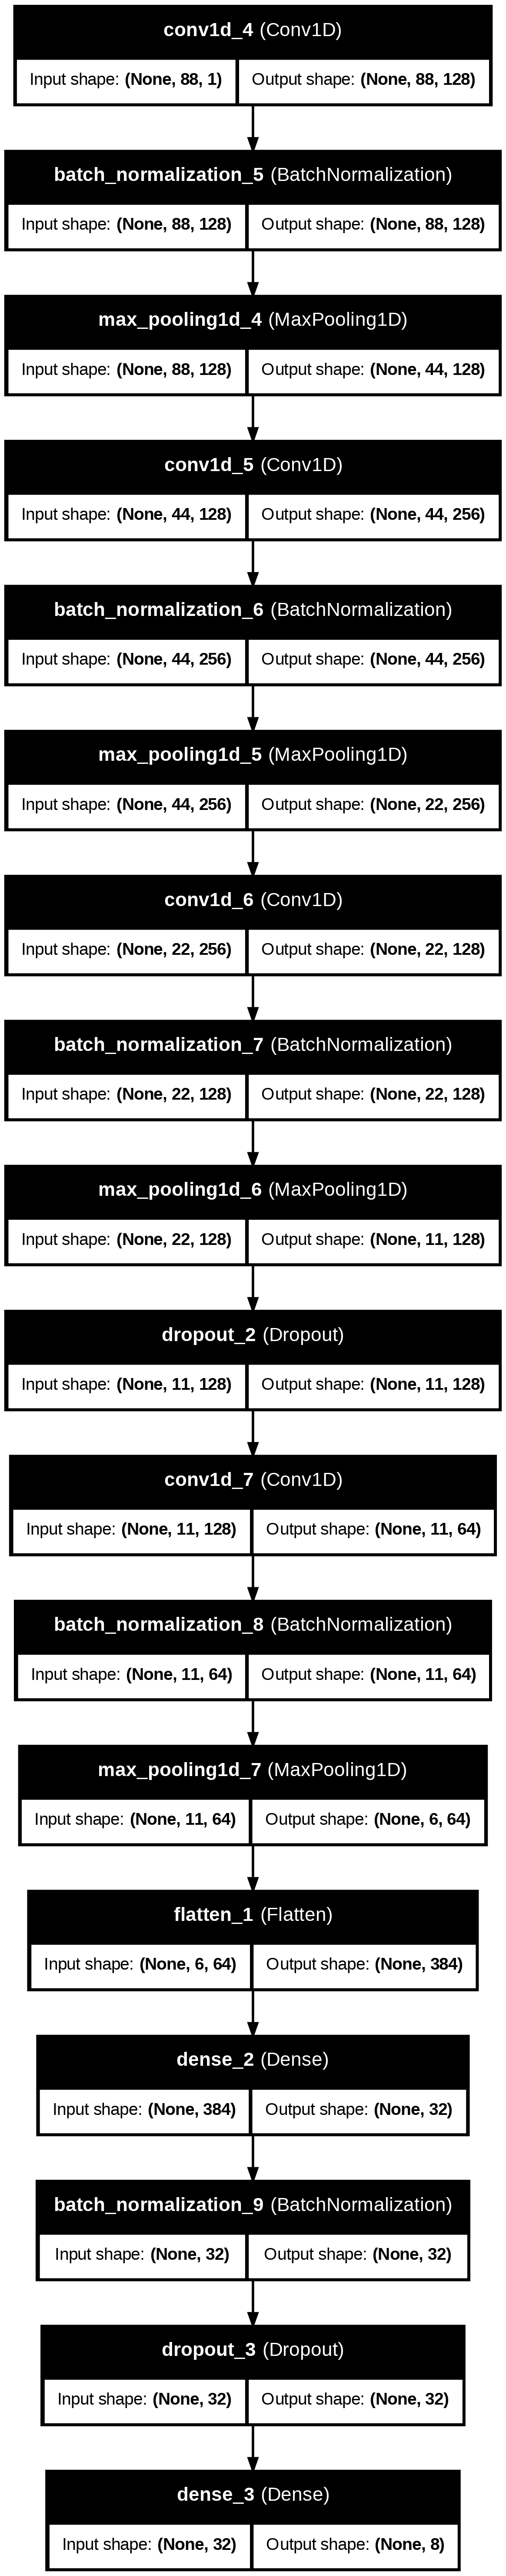

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)
callbacks=[learning_rate_reduction]

Epoch 1/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.2142 - loss: 2.2914 - val_accuracy: 0.1689 - val_loss: 2.2828
Epoch 2/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.2808 - loss: 1.9017 - val_accuracy: 0.3322 - val_loss: 1.7758
Epoch 3/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3323 - loss: 1.7516 - val_accuracy: 0.3925 - val_loss: 1.7115
Epoch 4/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3484 - loss: 1.6883 - val_accuracy: 0.3717 - val_loss: 1.6636
Epoch 5/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.3688 - loss: 1.6290 - val_accuracy: 0.4002 - val_loss: 1.8174
Epoch 6/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.4247 - loss: 1.5468 - val_accuracy: 0.4035 - val_loss: 1.5828
Epoch 7/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4220 - loss: 1.5348 - val_accuracy: 0.4463 - val_loss: 1.5377
Epoch 8/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4511 - loss: 1

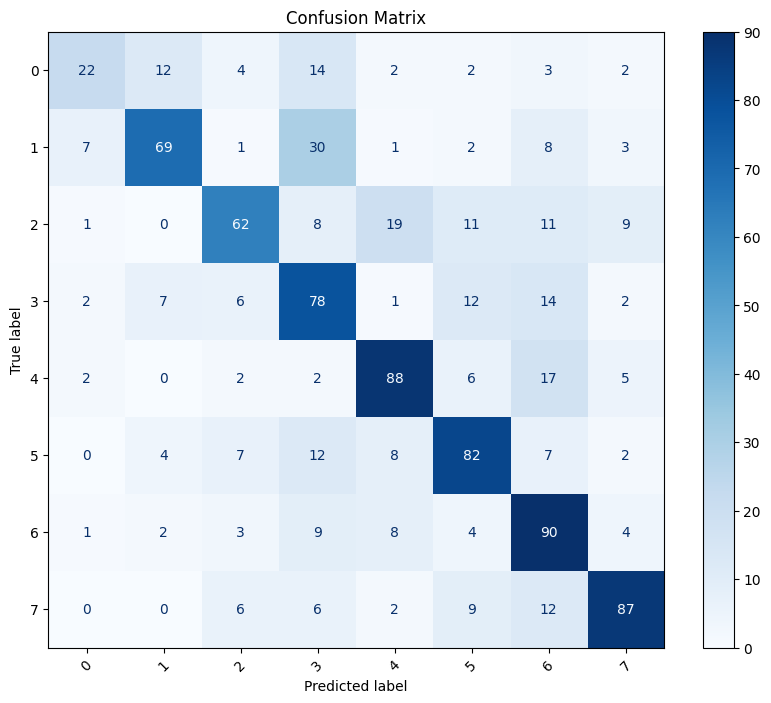

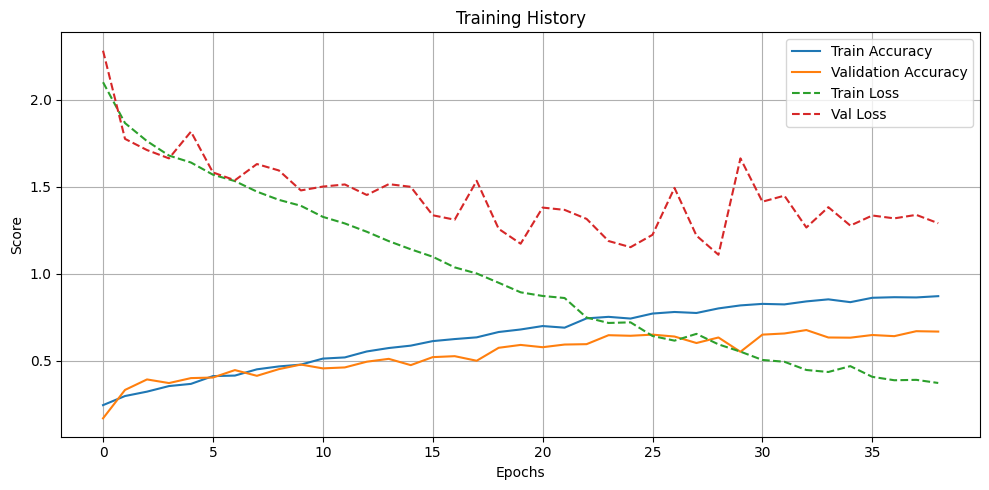

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)
callbacks=[learning_rate_reduction]

# --- 8. Train with early stopping and class weights ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 9. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 10. Classification Report and Confusion Matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

# Ensure class labels are strings for report and confusion matrix
class_names = [str(cls) for cls in encoder.classes_]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix with string labels
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 11. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# LSTM

In [ ]:
import pandas as pd
# --- 1. Load CSV file ---
file_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Acusticos/AUG_RAVDESS_eGeMAPS._features.csv"
df_combined = pd.read_csv(file_path)

In [ ]:
# Drop unwanted columns
columns_to_exclude = ['File', 'Root', 'Path']
df_combined = df_combined.drop(columns=columns_to_exclude, errors='ignore')

In [ ]:
df_combined

,Emotion,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,3,38.905033,0.091265,37.797726,39.689980,41.622690,3.824963,43.138298,21.716740,34.886124,...,0.021230,0.002956,0.087659,1.804124,1.044386,0.347500,0.202531,0.470000,0.473117,-33.050503
1,3,38.304432,0.142300,35.072640,38.785248,42.334210,7.261570,58.333336,28.486038,80.047290,...,-0.018445,0.008135,0.084763,1.960784,1.736973,0.175714,0.083471,0.331250,0.494379,-25.157513
2,6,30.317131,0.110858,27.415815,28.480635,34.136734,6.720919,17.519499,7.831558,103.652790,...,-0.026291,0.014928,0.011247,1.449275,1.176471,0.257500,0.261761,0.567500,0.512366,-38.207733
3,2,27.037003,0.104649,24.721802,26.227253,29.451542,4.729740,20.070581,10.580526,15.709426,...,0.006650,0.005508,0.002587,1.012146,1.022495,0.306000,0.087544,0.541667,0.536079,-50.002537
4,5,42.740055,0.103469,40.645220,43.064568,46.791767,6.146545,123.399610,123.972450,57.134296,...,0.012463,0.004766,0.043072,1.279318,1.293103,0.273333,0.137800,0.476667,0.597653,-24.294119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,6,52.950798,0.058752,50.656742,53.947727,55.411533,4.754791,34.120930,12.730889,19.674810,...,0.073699,0.001776,0.005290,1.574803,0.265957,1.740000,0.000000,0.995000,0.005000,-28.526997
4556,1,36.458992,0.065941,34.461220,36.229794,38.592080,4.130859,7.694566,3.785384,-3.255896,...,0.020768,0.001381,0.002907,1.182033,1.674641,0.167143,0.098375,0.352500,0.484116,-52.075024
4557,2,24.068619,0.083231,22.087950,23.835627,26.276535,4.188585,55.914886,50.899920,16.631817,...,0.035760,0.004545,0.017071,1.993356,1.351351,0.217500,0.110764,0.400000,0.445152,-47.597874
4558,3,27.636768,0.123210,24.110992,26.985666,31.601067,7.490074,21.763632,7.035800,10.517553,...,0.028439,0.004423,0.035434,1.246106,1.265823,0.232500,0.133112,0.428000,0.434898,-41.734173


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import numpy as np




# --- 2. Split features and labels ---
X = df_combined.drop(columns=['Emotion'])  # Feature columns
y = df_combined['Emotion']                 # Label column

# --- 3. Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Standardize the features ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 5. Reshape input for Conv1D (add channel dimension) ---
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# --- 6. Encode emotion labels ---
encoder = LabelEncoder()
encoder.fit(y_train)
encoded_y_train = encoder.transform(y_train)
encoded_y_test = encoder.transform(y_test)

# One-hot encode the labels
dummy_y_train = to_categorical(encoded_y_train)
dummy_y_test = to_categorical(encoded_y_test)

# --- 7. Compute class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(encoded_y_train),
    y=encoded_y_train
)
class_weight_dict = dict(zip(np.unique(encoded_y_train), class_weights))

print("x_train:", x_train.shape)
print("dummy_y_train:", dummy_y_train.shape)

x_train: (3648, 88, 1)
dummy_y_train: (3648, 8)


In [ ]:
print("x_train:", x_train.shape)
print("dummy_y_train:", dummy_y_train.shape)

x_train: (3648, 88, 1)
dummy_y_train: (3648, 8)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation, Input

def create_model_LSTM():
    model = Sequential()
    model.add(Input(shape=(88, 1)))  # Adjusting to (88, 1) as per your data
    model.add(LSTM(128, return_sequences=False))
    model.add(Dense(64))
    model.add(Dropout(0.4))
    model.add(Activation('relu'))
    model.add(Dense(32))
    model.add(Dropout(0.4))
    model.add(Activation('relu'))
    model.add(Dense(8))  # Output layer with 8 classes
    model.add(Activation('softmax'))

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model

In [ ]:
# Train the model
model = create_model_LSTM()

Epoch 1/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1788 - loss: 2.0490 - val_accuracy: 0.2818 - val_loss: 1.8307 - learning_rate: 0.0010
Epoch 2/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2567 - loss: 1.8662 - val_accuracy: 0.2961 - val_loss: 1.7854 - learning_rate: 0.0010
Epoch 3/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2764 - loss: 1.8169 - val_accuracy: 0.3202 - val_loss: 1.7435 - learning_rate: 0.0010
Epoch 4/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3004 - loss: 1.7614 - val_accuracy: 0.3180 - val_loss: 1.7351 - learning_rate: 0.0010
Epoch 5/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3036 - loss: 1.7638 - val_accuracy: 0.3136 - val_loss: 1.7462 - learning_rate: 0.0010
Epoch 6/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2926 - loss: 1.7619 - val_accuracy: 0.3300 - val_loss: 1.7010 - learning_rate: 0.0010
Epoch 7/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3024 - los

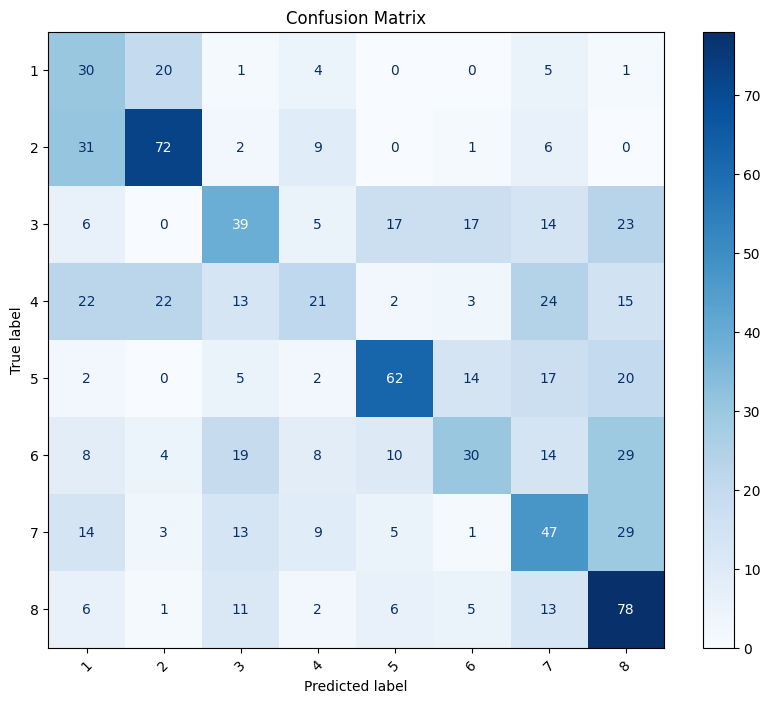

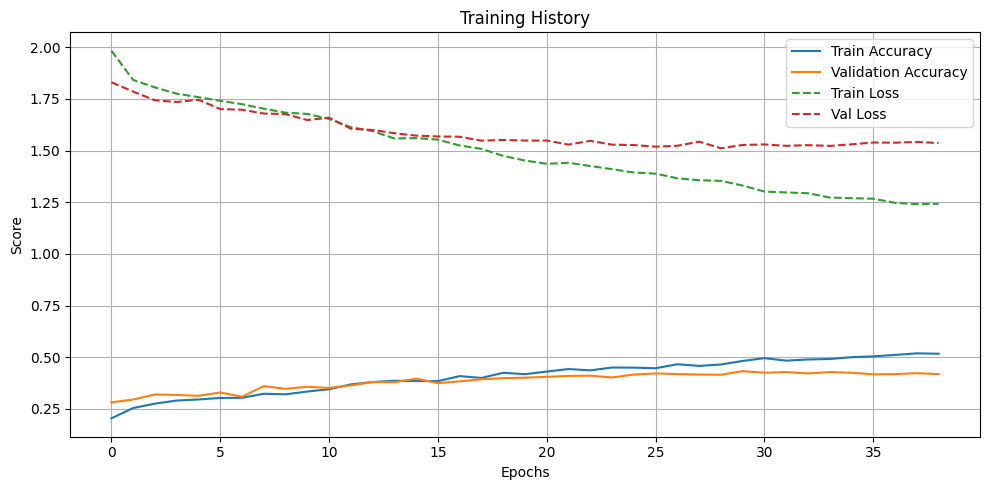

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Learning rate reduction ---
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',  # corrected monitor name
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-5
)

# --- 2. Early stopping ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# --- 3. Train the model ---
history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop, learning_rate_reduction],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 4. Evaluate ---
loss, accuracy = model.evaluate(x_test, dummy_y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 5. Classification report and confusion matrix ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

# Ensure class labels are strings
class_names = [str(cls) for cls in encoder.classes_]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 6. Plot training history ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## CNN + LSTM

Epoch 1/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.1909 - loss: 2.2297 - val_accuracy: 0.1546 - val_loss: 2.2002 - learning_rate: 0.0010
Epoch 2/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.2695 - loss: 1.8952 - val_accuracy: 0.2961 - val_loss: 1.8059 - learning_rate: 0.0010
Epoch 3/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3242 - loss: 1.7730 - val_accuracy: 0.3037 - val_loss: 1.9616 - learning_rate: 0.0010
Epoch 4/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3359 - loss: 1.7500 - val_accuracy: 0.3004 - val_loss: 1.7334 - learning_rate: 0.0010
Epoch 5/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3848 - loss: 1.6238 - val_accuracy: 0.3882 - val_loss: 1.5798 - learning_rate: 0.0010
Epoch 6/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4034 - loss: 1.5571 - val_accuracy: 0.4276 - val_loss: 1.5414 - learning_rate: 0.0010
Epoch 7/150
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4390

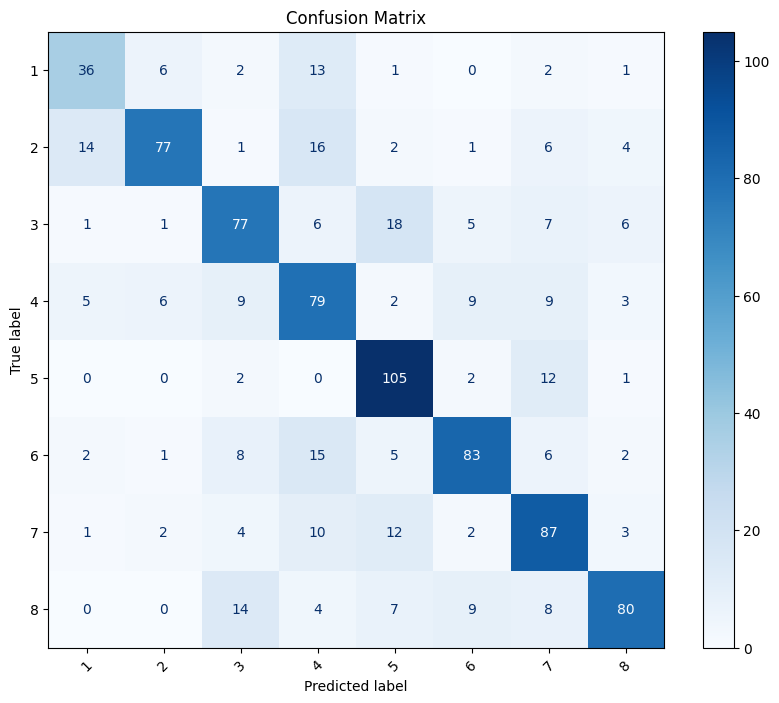

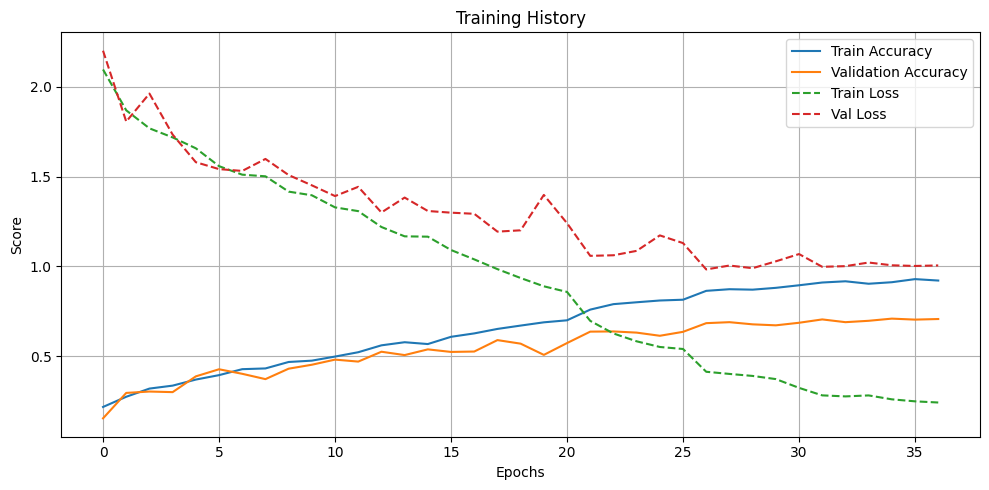

In [ ]:
# --- 1. Imports ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Dropout, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 2. Define the CNN-LSTM Model ---
def create_cnn_lstm_model():
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1], 1)))  # shape: (88, 1)

    model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))

    model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))

    model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))
    model.add(Dropout(0.2))

    model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))

    model.add(LSTM(64, return_sequences=False))  # LSTM over CNN features

    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(8, activation='softmax'))  # 8 emotion classes

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 3. Define Callbacks ---
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-5
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# --- 4. Train the Model ---
model = create_cnn_lstm_model()

history = model.fit(
    x_train, dummy_y_train,
    epochs=150,
    batch_size=10,
    validation_data=(x_test, dummy_y_test),
    callbacks=[early_stop, learning_rate_reduction],
    class_weight=class_weight_dict,
    verbose=1
)

# --- 5. Evaluate Model ---
loss, accuracy = model.evaluate(x_test, dummy_y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# --- 6. Predict and Report ---
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(dummy_y_test, axis=1)

class_names = [str(cls) for cls in encoder.classes_]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# --- 7. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# --- 8. Plot Training History ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
